# 10a — Vanilla DT (16GB GPU · bf16 · torch.compile)

Optimized variant of `10_vanilla_dt.ipynb` for a single 16 GB NVIDIA GPU.

**Changes vs. notebook 10:**

- `bfloat16` autocast around train + val forward (no `GradScaler` needed for bf16)
- `torch.compile(model, mode='reduce-overhead')` on the training forward
- TF32 matmul precision + `cudnn.benchmark = True`
- `BATCH_SIZE = 256`, `NUM_WORKERS = 4` (CUDA only), `pin_memory = True`
- Stackable HTML output panels — each top-level cell renders a uniform card

Everything else (data pipeline, model architecture, RTG semantics, probe loop) is identical to notebook 10.


## 1. Configuration

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import html as _html
import torch
from IPython.display import display, HTML


# ── Stackable output panel helper ────────────────────────────────────────
_PANEL_CSS_INJECTED = False
def panel(title: str, rows, *, kind: str = 'info') -> None:
    """Render a stackable HTML card.

    rows: list of (label, value) tuples OR a single HTML string for body content.
    kind: 'info' | 'ok' | 'warn' | 'err' — colours the title bar.
    """
    global _PANEL_CSS_INJECTED
    if not _PANEL_CSS_INJECTED:
        display(HTML("""
        <style>
        .nbpanel { border:1px solid #d0d7de; border-radius:6px; margin:6px 0;
                   font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;
                   font-size:12px; overflow:hidden; }
        .nbpanel-title { padding:5px 10px; font-weight:600; color:#fff;
                         font-family:ui-monospace,SFMono-Regular,Menlo,monospace; }
        .nbpanel-info { background:#0969da; }
        .nbpanel-ok   { background:#1a7f37; }
        .nbpanel-warn { background:#9a6700; }
        .nbpanel-err  { background:#cf222e; }
        .nbpanel-body { padding:8px 10px; background:#f6f8fa; }
        .nbpanel-body table { border-collapse:collapse; width:100%; }
        .nbpanel-body td { padding:2px 8px 2px 0; vertical-align:top;
                           font-family:ui-monospace,SFMono-Regular,Menlo,monospace; }
        .nbpanel-body td.k { color:#57606a; white-space:nowrap; width:1%; }
        .nbpanel-body td.v { color:#1f2328; word-break:break-word; }
        </style>
        """))
        _PANEL_CSS_INJECTED = True

    if isinstance(rows, str):
        body = rows
    else:
        body = '<table>' + ''.join(
            f'<tr><td class="k">{_html.escape(str(k))}</td>'
            f'<td class="v">{_html.escape(str(v))}</td></tr>'
            for k, v in rows
        ) + '</table>'

    display(HTML(
        f'<div class="nbpanel">'
        f'<div class="nbpanel-title nbpanel-{kind}">{_html.escape(title)}</div>'
        f'<div class="nbpanel-body">{body}</div>'
        f'</div>'
    ))


# ── Experiment identity ─────────────────────────────────────
RUN_NAME         = 'dt-vanilla-pi-cm016-bf16'
EXPERIMENT_NOTES = 'Vanilla DT (10a optimized): bf16 + torch.compile for 16GB NVIDIA GPU.'

# ── Subject / group / session sequence ──────────────────────────
TRAINING_GROUP = 'pi_vc'                          # 'pi' | 'pi_vc' | 'vc'
SUBJECTS       = ['CM016']
POOL_SUBJECTS  = False

SESSION_TYPES  = [
    'PI+VC f2 acquisition',
    'PI+VC f2 novel route',
    'PI+VC f2 no cue',
    'PI+VC f2 rotate',
    'PI+VC f2 reversal',
]
ACQ_INFERENCE_TRIALS = 32

# ── Seed sweep ────────────────────────────────────────────
N_RUNS = 5

# ── Reward / cost (LOCKED across train + eval) ──
@dataclass(frozen=True)
class CostConfig:
    terminal_reward: float = 1.0
    step_cost: float       = 0.001
COST = CostConfig()

# ── Inference-only RTG conditioning ───────────────────────────
LAST_N_ACQ_FOR_RTG = 2
EXPECTED_OPT_LEN   = None
INFERENCE_RTG      = None

# ── Windowing ─────────────────────────────────────────────
K = 128

# ── State encoder ──────────────────────────────────────────
ENCODER_TYPE   = 'pose_visual'
ENCODER_DIM    = 60
FREEZE_ENCODER = True

# ── DT architecture (kzl gym defaults, embed_dim aligned to 60D encoder) ───
HIDDEN_DIM   = 60
N_LAYERS     = 3
N_HEADS      = 4
DROPOUT      = 0.1
MAX_EP_LEN   = None
NUM_ACTIONS  = 5
ACTION_MASK_INFERENCE = False

# ── Training (16GB GPU tuned) ────────────────────────────────────────────
N_EPOCHS              = 50
BATCH_SIZE            = 1024                  # 4× kzl default; tiny model + bf16 makes 16GB ample
LEARNING_RATE         = 1e-4
WEIGHT_DECAY          = 1e-4
WARMUP_STEPS          = None
GRAD_CLIP             = 0.25
EARLY_STOP_PATIENCE   = 5
VAL_FRAC              = 0.15

# ── GPU optimization toggles ─────────────────────────────────────────────
USE_BF16           = True                    # bf16 autocast on train + val forward
USE_TORCH_COMPILE  = True                    # torch.compile(model, mode=COMPILE_MODE)
COMPILE_MODE       = 'reduce-overhead'       # best for small models (kernel-launch bound)
USE_TF32           = True                    # enables tf32 matmul on Ampere+
CUDNN_BENCHMARK    = True                    # pick fastest cudnn algorithm per shape

# ── Logging / output toggles ─────────────────────────────────
SHOW_TQDM                = True
PRINT_EVERY_N_BATCHES    = 0
SAVE_PER_BATCH_LOSS      = False
SAVE_ATTENTION_PER_EPOCH = False

# ── Probe / eval ────────────────────────────────────────────
EVAL_EPISODES_PER_PROBE = 1
FROZEN_DETERMINISTIC    = False
SAVE_PROBE_ATTENTION    = True

# ── Pipeline gating ─────────────────────────────────────────
ACQ_PASS_COMPLETED_TRIALS = 24

# ── Device + DataLoader workers ──────────────────────────────────────────
FORCE_CPU = False
if FORCE_CPU:
    DEVICE = 'cpu'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

NUM_WORKERS = 4 if DEVICE == 'cuda' else 0

# Apply CUDA-specific perf knobs once at config time.
if DEVICE == 'cuda':
    if USE_TF32:
        torch.set_float32_matmul_precision('high')
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    if CUDNN_BENCHMARK:
        torch.backends.cudnn.benchmark = True

# bf16 only makes sense on cuda; downgrade silently elsewhere.
EFFECTIVE_BF16 = USE_BF16 and DEVICE == 'cuda' and torch.cuda.is_bf16_supported()
EFFECTIVE_COMPILE = USE_TORCH_COMPILE and DEVICE == 'cuda'

REPO_ROOT     = Path.cwd().parent
ARTIFACT_ROOT = REPO_ROOT / 'data' / 'runs' / RUN_NAME

# ── Render config as a stackable panel ───────────────────────────────────
_gpu_name = torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '—'
_gpu_mem  = (f'{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GiB'
             if DEVICE == 'cuda' else '—')

panel('cell 2 · configuration', [
    ('RUN_NAME',      RUN_NAME),
    ('SUBJECTS',      f'{SUBJECTS}  (group={TRAINING_GROUP}, pool={POOL_SUBJECTS})'),
    ('N_RUNS · K',    f'{N_RUNS} · {K}'),
    ('encoder',       f'{ENCODER_TYPE} / {ENCODER_DIM}D (frozen={FREEZE_ENCODER})'),
    ('DT',            f'h={HIDDEN_DIM} · L={N_LAYERS} · H={N_HEADS} · dropout={DROPOUT}'),
    ('train',         f'epochs={N_EPOCHS} · batch={BATCH_SIZE} · lr={LEARNING_RATE} · wd={WEIGHT_DECAY}'),
    ('cost (locked)', f'R={COST.terminal_reward} · c={COST.step_cost}'),
    ('device',        f'{DEVICE}  ({_gpu_name}, {_gpu_mem})'),
    ('bf16 autocast', f'{EFFECTIVE_BF16}  (requested={USE_BF16})'),
    ('torch.compile', f'{EFFECTIVE_COMPILE}  (mode={COMPILE_MODE})'),
    ('TF32 matmul',   f'{USE_TF32 and DEVICE == "cuda"}'),
    ('cudnn.benchmark', f'{CUDNN_BENCHMARK and DEVICE == "cuda"}'),
    ('num_workers',   NUM_WORKERS),
    ('ARTIFACT_ROOT', str(ARTIFACT_ROOT)),
], kind='ok' if DEVICE == 'cuda' else 'warn')


RUN_NAME,dt-vanilla-pi-cm016-bf16
SUBJECTS,"['CM016'] (group=pi_vc, pool=False)"
N_RUNS · K,5 · 128
encoder,pose_visual / 60D (frozen=True)
DT,h=60 · L=3 · H=4 · dropout=0.1
train,epochs=50 · batch=1024 · lr=0.0001 · wd=0.0001
cost (locked),R=1.0 · c=0.001
device,"cuda (NVIDIA GeForce RTX 4080 SUPER, 15.6 GiB)"
bf16 autocast,True (requested=True)
torch.compile,True (mode=reduce-overhead)
TF32 matmul,True


## 2. Subject ↔ group validation + training units + paths

For each subject in `SUBJECTS`, look up its training group in `subjects.parquet` and assert it matches `TRAINING_GROUP`.

Then materialize `TRAINING_UNITS` — the actual loop axis for cells 3-10:

- `POOL_SUBJECTS=False` → one unit per subject (`subject_CM023`, `subject_CM024`, …); each becomes an independent model.
- `POOL_SUBJECTS=True`  → one unit (`pooled_pi_vc`) whose dataset is built from all `SUBJECTS`; one model.

Per-unit layout:
```
data/runs/{RUN_NAME}_{timestamp}/
    {unit_label}/                          # subject_CM023 OR pooled_pi_vc
        seed_{N}/
            run_config.json
            curves.parquet
            model_best.pt
            acq_inference.parquet
            episode_data.parquet
            trial_metrics.parquet
            attention/                     (if SAVE_PROBE_ATTENTION)
```

In [2]:
from datetime import datetime, timezone
import pandas as pd

from corner_maze_rl.data.session_types import assert_subject_group_match

# Map our short codes → labels stored in subjects.parquet's training_group column.
GROUP_ALIASES = {'pi': 'PI', 'pi_vc': 'PI+VC', 'vc': 'VC', 'pi_vc_f1': 'PI+VC_f1'}
assert TRAINING_GROUP in GROUP_ALIASES, f"Unknown TRAINING_GROUP={TRAINING_GROUP!r}"
assert len(SUBJECTS) >= 1, "SUBJECTS must contain at least one subject"

subjects_path = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'subjects.parquet'
subjects_df   = pd.read_parquet(subjects_path)

for subj in SUBJECTS:
    row = subjects_df[subjects_df['subject_name'] == subj]
    if row.empty:
        raise ValueError(f'SUBJECT={subj!r} not found in {subjects_path}')
    subj_group = row.iloc[0].get('training_group') or row.iloc[0].get('group')
    assert_subject_group_match(
        training_group=GROUP_ALIASES[TRAINING_GROUP],
        subject_training_group=subj_group,
    )
    print(f'  ✓ {subj:10s}  group={subj_group}  → matches TRAINING_GROUP={TRAINING_GROUP}')

# ── Build TRAINING_UNITS — the loop axis for cells 3-10 ────────────────
@dataclass(frozen=True)
class TrainingUnit:
    label:    str          # 'subject_CM023' or 'pooled_pi_vc'
    subjects: tuple[str, ...]  # which subjects' yoked data feed this unit's dataset

if POOL_SUBJECTS:
    TRAINING_UNITS = [TrainingUnit(label=f'pooled_{TRAINING_GROUP}', subjects=tuple(SUBJECTS))]
else:
    TRAINING_UNITS = [TrainingUnit(label=f'subject_{s}', subjects=(s,)) for s in SUBJECTS]

# ── Output paths ─────────────────────────────────────────
TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
RUN_ROOT  = ARTIFACT_ROOT.with_name(f'{RUN_NAME}_{TIMESTAMP}')
RUN_ROOT.mkdir(parents=True, exist_ok=True)

def unit_dir(unit: TrainingUnit) -> Path:
    d = RUN_ROOT / unit.label
    d.mkdir(parents=True, exist_ok=True)
    return d

def seed_dir(unit: TrainingUnit, seed: int) -> Path:
    d = unit_dir(unit) / f'seed_{seed}'
    d.mkdir(parents=True, exist_ok=True)
    if SAVE_PROBE_ATTENTION:
        (d / 'attention').mkdir(exist_ok=True)
    return d

print()
print(f'RUN_ROOT       = {RUN_ROOT}')
print(f'TRAINING_UNITS = {len(TRAINING_UNITS)}  (pool={POOL_SUBJECTS})')
for u in TRAINING_UNITS:
    print(f'  - {u.label:24s}  subjects={list(u.subjects)}')
print('session sequence (probes):')
for st in SESSION_TYPES:
    print(f'  - {st}')


  ✓ CM016       group=PI+VC  → matches TRAINING_GROUP=pi_vc

RUN_ROOT       = /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632
TRAINING_UNITS = 1  (pool=False)
  - subject_CM016             subjects=['CM016']
session sequence (probes):
  - PI+VC f2 acquisition
  - PI+VC f2 novel route
  - PI+VC f2 no cue
  - PI+VC f2 rotate
  - PI+VC f2 reversal


## 3. Load yoked data + compute RTG + derive run-level constants

Four things, in order:

**(a) State lookup table.** Branches on `ENCODER_TYPE` — each npz has a different schema and indexing convention:

| `ENCODER_TYPE` | npz file | rows | what each row stores | per-step index |
|---|---|---|---|---|
| `pose_visual` | `pose_visual.npz` | 295 | 60D float32 image embedding | `pose_to_idx[pose_labels.index(label)]` (4536→295 indirection) |
| `grid_cell`   | `grid_cells_60d.npz` | 484 | 60D float32 grid-cell vector | `((x-1)*11 + (y-1))*4 + d` (verified matches the npz `keys` ordering) |
| `image_cnn`   | `minigrid_views.npz` | 5212 | 21×21×3 uint8 view | `pose_labels.index(label)` (1-to-1) |

Per-step state is stored as `int32 state_idx`, and the model expands it via `STATE_LOOKUP` at batch time. RAM-cheap, GPU-friendly.

**(b) Subject filter via join.** `actions_real_pretrial.parquet` has only `session_id` — no `subject_name`. Join path: `actions.session_id → sessions.subject_id → subjects.subject_name`.

**(c) Canonical-frame rotation (PI/PI+VC).** PI and PI+VC subjects are rotated so the cue lands at North in every session, matching the rat's internal (path-integration) frame. Per-session rotation count = cue index of the first trial (`0=N → 0 rotations, 1=E → 1, 2=S → 2, 3=W → 3`). VC subjects skip rotation — rotating cue **is** the VC training signal.

The rotation is built into the pipeline unconditionally (skipping only for VC) so the encoder choice doesn't have to know about it. By encoder:
| Encoder | Effect of rotation on DT input stream |
|---|---|
| `pose_visual` | **No-op** — `pose_visual.npz`'s 4536→295 collapse already encodes 4-fold rotational symmetry. Rotated and unrotated labels map to identical embedding rows (verified across 491K rows of PI/PI+VC acq data). |
| `image_cnn`   | **No-op** — `minigrid_views.npz` views are byte-identical across rotational equivalents (verified by sampling). |
| `grid_cell`   | **Substantive** — vectors are indexed by absolute `(x, y, d)`, so rotation moves to a different cell with a different 60D vector. Rotation is essential for this encoder mode. |

**Direction formula correction**: legacy `rotate_to_canonical.py:62` uses `(d + n) % 4` for direction rotation, which is **wrong** for `n ∈ {1, 3}` (accidentally correct for `n=2` due to 180° symmetry). Empirical trace: agent at (8, 6) facing E (d=0) walking forward to (9, 6) — after 1 CCW rotation, positions map (8,6)→(6,4) and (9,6)→(6,3), a step in −y direction = N (d=3). Legacy gives `(0+1)%4 = 1 = S` (180° wrong). We use the corrected formula `(d − n) % 4`. The legacy bug stayed buried because their validation only checked rewarded positions, never directions.

**Multi-cue defensive**: if a PI/PI+VC session has cue varying within the session (shouldn't happen for canonical scope; 0 observed in our dataset), we drop it with a warning rather than guessing a rotation.

**(d) `trial_timestep` — deviation from kzl.** kzl's `embed_t` indexes by step *within episode* (their MuJoCo episodes are ≤1000 steps). We use `embed_t` indexed by step *within trial*. Rationale:
- Our sessions are 2-3× longer than kzl's episodes (~2000-3000 steps).
- Our dataset is 2-3 orders of magnitude smaller (5-6 sessions/rat vs ~1000 episodes per D4RL split).
- A per-session signal puts almost zero samples on high-position embeddings (only sessions long enough to reach step 1500 train `embed_t[1500]`).
- A per-trial signal puts ~32 trials/session × N sessions ≈ 100s of samples on every `embed_t[i]` for `i < typical_trial_len`.
- `MAX_EP_LEN` shrinks from ~3000 to ~250, cutting the learned timestep embedding table by ~12×.

The trial-level signal is also more meaningful for the task: `embed_t[5]` consistently means "5 steps into a trial," not "5 steps into wherever this session happened to start."

**(e) Derive globals.** Fill in the four constants left as `None` in Cell 1:

| Constant | Derived from |
|---|---|
| `EXPECTED_OPT_LEN` | `median(trial_start_a2r)` over `LAST_N_ACQ_FOR_RTG` late-acq sessions per subject |
| `INFERENCE_RTG` | `R − c · EXPECTED_OPT_LEN` |
| `MAX_EP_LEN` | `max(trial_length)` rounded up to next 50 — sets the learned timestep embedding size (per-trial, not per-session) |
| `WARMUP_STEPS` | `~5%` of total optimizer steps, clamped to `[100, 10000]` |

Trial-start rule: a step `t` starts a trial iff `t == 0` OR `actions_to_reward[t] > actions_to_reward[t-1]` (the count "resets up" at trial start, decreases monotonically to 0 at reward).

In [3]:
import math
import json
import numpy as np

# ── Paths ─────────────────────────────────────────────────
YOKED_PARQUET    = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'actions_real_pretrial.parquet'
SESSIONS_PARQUET = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'sessions.parquet'
LOOKUPS_DIR      = REPO_ROOT / 'data' / 'lookups'

# Grid-cell indexing convention (matches the .npz `keys` ordering — verified).
N_X, N_Y, N_D = 11, 11, 4

# ── Canonical-frame rotation helpers ──────────────────────────
# Single CCW rotation (visually CCW in screen coordinates, y-down):
#   position: (x, y) → (y, 12 − x)  — maps cue at E (11,6) → cue at N (6,1)
#   direction: (d − n) % 4          — CORRECTED from legacy `(d + n)` which is wrong
#                                     for n ∈ {1, 3} and only accidentally right at n=2.
#   letter (arm/cue): n → w → s → e → n
#   goal corner:     ne → nw → sw → se → ne
# pose_label format: {phase}_{arm}_{cue}_{goal_or_xx}_{x}_{y}_{d}
ARM_CUE_CCW = {'n': 'w', 'w': 's', 's': 'e', 'e': 'n', 'x': 'x'}
GOAL_CCW    = {'ne': 'nw', 'nw': 'sw', 'sw': 'se', 'se': 'ne', 'xx': 'xx'}

def _rotate_letter(c: str, n: int, table: dict) -> str:
    for _ in range(n % 4):
        c = table[c]
    return c

def _rotate_pos_scalar(x: int, y: int, n: int) -> tuple[int, int]:
    for _ in range(n % 4):
        x, y = y, 12 - x
    return x, y

def _rotate_pos_vec(x: np.ndarray, y: np.ndarray, n: int) -> tuple[np.ndarray, np.ndarray]:
    rx, ry = x.copy(), y.copy()
    for _ in range(n % 4):
        rx, ry = ry.copy(), 12 - rx
    return rx, ry

def rotate_pose_label(label: str, n: int) -> str:
    """Rotate a pose_label by n CCW rotations. Exposure phases unchanged (no anchoring)."""
    parts = label.split('_')
    if parts[0] in ('expa', 'expb') or len(parts) < 7:
        return label
    phase, arm, cue, goal, xs, ys, ds = parts[:7]
    nx, ny = _rotate_pos_scalar(int(xs), int(ys), n)
    return (f'{phase}_{_rotate_letter(arm, n, ARM_CUE_CCW)}'
            f'_{_rotate_letter(cue, n, ARM_CUE_CCW)}'
            f'_{_rotate_letter(goal, n, GOAL_CCW)}'
            f'_{nx}_{ny}_{(int(ds) - n) % 4}')

ROTATE_TO_CANONICAL = GROUP_ALIASES[TRAINING_GROUP] in ('PI', 'PI+VC', 'PI+VC_f1')
print(f'rotate_to_canonical = {ROTATE_TO_CANONICAL}  (training_group={GROUP_ALIASES[TRAINING_GROUP]})')

# ── State lookup table — branches on ENCODER_TYPE ────────────────
if ENCODER_TYPE == 'pose_visual':
    npz = np.load(LOOKUPS_DIR / 'pose_visual.npz')
    pose_labels  = npz['pose_labels']
    pose_to_idx  = npz['pose_to_idx'].astype(np.int32)
    STATE_LOOKUP = npz['embeddings'].astype(np.float32)            # (295, 60)
    label_to_row = dict(zip(pose_labels.tolist(), pose_to_idx.tolist()))
    assert len(label_to_row) == len(pose_labels), 'duplicate pose_labels in pose_visual.npz'
elif ENCODER_TYPE == 'image_cnn':
    npz = np.load(LOOKUPS_DIR / 'minigrid_views.npz')
    pose_labels  = npz['pose_labels']
    STATE_LOOKUP = npz['views']                                    # (5212, 21, 21, 3) uint8
    label_to_row = {lbl: i for i, lbl in enumerate(pose_labels.tolist())}
elif ENCODER_TYPE == 'grid_cell':
    npz = np.load(LOOKUPS_DIR / 'grid_cells_60d.npz')
    STATE_LOOKUP = npz['vectors'].astype(np.float32)               # (484, 60)
    label_to_row = None                                            # uses (x, y, d) instead of pose_label
else:
    raise ValueError(f"Unknown ENCODER_TYPE={ENCODER_TYPE!r}")

STATE_LOOKUP_SIZE = STATE_LOOKUP.shape[0]
print(f'STATE_LOOKUP[{ENCODER_TYPE}]  shape={STATE_LOOKUP.shape}  dtype={STATE_LOOKUP.dtype}')

# ── Resolve SUBJECTS → session_ids via subject join ───────────────
sessions_df_full = pd.read_parquet(SESSIONS_PARQUET)
subj_ids = subjects_df.loc[subjects_df['subject_name'].isin(SUBJECTS), 'subject_id'].tolist()
target_sessions = sessions_df_full[sessions_df_full['subject_id'].isin(subj_ids)].copy()
id_to_name = dict(zip(subjects_df['subject_id'].tolist(), subjects_df['subject_name'].tolist()))
target_sessions['subject_name'] = target_sessions['subject_id'].map(id_to_name)
sid_to_subject = dict(zip(target_sessions['session_id'].tolist(),
                          target_sessions['subject_name'].tolist()))
sid_to_phase   = dict(zip(target_sessions['session_id'].tolist(),
                          target_sessions['session_phase'].tolist()))
sid_to_snum    = dict(zip(target_sessions['session_id'].tolist(),
                          target_sessions['session_number'].tolist()))
print(f'subject session_ids: {sorted(target_sessions["session_id"].tolist())}')

# ── Per-session n_rotations + drop multi-cue PI/PI+VC sessions ─────
def _compute_n_rotations(target_sessions_df: pd.DataFrame) -> dict[int, int]:
    """Map session_id → n_rotations.
       0 for VC subjects; cue_index of first trial for PI/PI+VC.
       Drops multi-cue PI/PI+VC sessions (defensive; 0 observed in scope)."""
    out, dropped = {}, []
    for _, row in target_sessions_df.iterrows():
        sid = int(row['session_id'])
        if not ROTATE_TO_CANONICAL:
            out[sid] = 0
            continue
        tc_json = row.get('trial_configs')
        if tc_json is None or (isinstance(tc_json, float) and np.isnan(tc_json)):
            out[sid] = 0
            continue
        try:
            tc = json.loads(tc_json) if isinstance(tc_json, str) else list(tc_json)
        except Exception:
            out[sid] = 0
            continue
        if not tc:
            out[sid] = 0
            continue
        cues = set(t[1] for t in tc)
        if len(cues) > 1:
            dropped.append(sid)
            continue
        out[sid] = int(list(cues)[0])
    if dropped:
        print(f'  [warn] dropping {len(dropped)} multi-cue session(s) (PI/PI+VC scope): {dropped}')
    return out

sid_to_nrot = _compute_n_rotations(target_sessions)
print(f'n_rotations per session: {dict(sorted(sid_to_nrot.items()))}')

# ── Load yoked rows filtered to (target_sessions minus dropped) ──
df = pd.read_parquet(YOKED_PARQUET)
df = df[df['session_id'].isin(sid_to_nrot.keys())].reset_index(drop=True)
df['subject_name'] = df['session_id'].map(sid_to_subject)
df['n_rot']        = df['session_id'].map(sid_to_nrot).astype(np.int32)
print(f'rows={len(df):,}  sessions={df["session_id"].nunique()}  subjects={df["subject_name"].nunique()}')
print(f'n_rotations distribution across rows: {dict(df["n_rot"].value_counts().sort_index())}')

# ── Schema check ──────────────────────────────────────────
required_cols = {'session_id', 'step', 'action', 'actions_to_reward', 'pose_label',
                 'grid_x', 'grid_y', 'direction'}
missing = required_cols - set(df.columns)
assert not missing, f'parquet is missing required columns: {missing}'
assert pd.api.types.is_string_dtype(df['pose_label']), f"pose_label is {df['pose_label'].dtype}, expected a string dtype"

# ── Apply rotation: produce rotated_x, rotated_y, rotated_direction, rotated_pose_label ──
rotated_x_all = np.empty(len(df), dtype=np.int32)
rotated_y_all = np.empty(len(df), dtype=np.int32)
for n_val in sorted(df['n_rot'].unique()):
    mask = (df['n_rot'].values == n_val)
    rx, ry = _rotate_pos_vec(df.loc[mask, 'grid_x'].to_numpy(np.int32),
                             df.loc[mask, 'grid_y'].to_numpy(np.int32), int(n_val))
    rotated_x_all[mask] = rx
    rotated_y_all[mask] = ry
df['rotated_x']          = rotated_x_all
df['rotated_y']          = rotated_y_all
df['rotated_direction']  = (df['direction'].to_numpy(np.int32) - df['n_rot'].to_numpy(np.int32)) % 4
# Per-row pose_label rotation (string-based; few-K unique labels so memoize)
_label_rot_cache: dict[tuple[str, int], str] = {}
def _rot_label_cached(lbl, n):
    key = (lbl, int(n))
    out = _label_rot_cache.get(key)
    if out is None:
        out = rotate_pose_label(lbl, int(n))
        _label_rot_cache[key] = out
    return out
df['rotated_pose_label'] = [
    _rot_label_cached(lbl, n) for lbl, n in zip(df['pose_label'].values, df['n_rot'].values)
]

# ── Per-session arrays ────────────────────────────────────
def _state_idx_for(grp: pd.DataFrame) -> np.ndarray:
    """Per-step int32 index into STATE_LOOKUP[ENCODER_TYPE], using ROTATED coords."""
    if ENCODER_TYPE == 'grid_cell':
        x = grp['rotated_x'].to_numpy(np.int32)
        y = grp['rotated_y'].to_numpy(np.int32)
        d = grp['rotated_direction'].to_numpy(np.int32)
        return (((x - 1) * N_Y + (y - 1)) * N_D + d).astype(np.int32)
    labels = grp['rotated_pose_label'].to_numpy()
    return np.fromiter((label_to_row[l] for l in labels),
                       dtype=np.int32, count=len(labels))

def build_sessions(df_subset: pd.DataFrame) -> list[dict]:
    out = []
    for (subj, sid), grp in df_subset.groupby(['subject_name', 'session_id'], sort=False):
        grp = grp.sort_values('step').reset_index(drop=True)
        L   = len(grp)
        a2r = grp['actions_to_reward'].to_numpy(np.int32)
        rtg = (COST.terminal_reward - COST.step_cost * a2r.astype(np.float32)).astype(np.float32)
        trial_start_mask = np.concatenate([[True], a2r[1:] > a2r[:-1]])

        trial_id = (np.cumsum(trial_start_mask) - 1).astype(np.int32)
        trial_start_positions = np.where(trial_start_mask)[0].astype(np.int32)
        trial_timestep = (np.arange(L, dtype=np.int32) - trial_start_positions[trial_id]).astype(np.int32)

        out.append({
            'subject':           subj,
            'session_id':        int(sid),
            'session_number':    sid_to_snum[sid],
            'session_phase':     sid_to_phase[sid],
            'n_rotations':       int(grp['n_rot'].iloc[0]),
            'state_idx':         _state_idx_for(grp),               # int32, in [0, STATE_LOOKUP_SIZE)
            'action':            grp['action'].to_numpy(np.int64),
            'actions_to_reward': a2r,
            'rtg':               rtg,
            'trial_id':          trial_id,                          # int32, 0..n_trials-1
            'trial_timestep':    trial_timestep,                    # int32, 0..L_trial-1, RESETS per trial
            'trial_start_mask':  trial_start_mask,
            'length':            L,
            # Diagnostics: keep raw and canonical for replay / debugging
            'pose_label_raw':       grp['pose_label'].to_numpy(),
            'pose_label_canonical': grp['rotated_pose_label'].to_numpy(),
            'grid_x_raw':           grp['grid_x'].to_numpy(np.int32),
            'grid_y_raw':           grp['grid_y'].to_numpy(np.int32),
            'direction_raw':        grp['direction'].to_numpy(np.int32),
            'grid_x_canonical':     grp['rotated_x'].to_numpy(np.int32),
            'grid_y_canonical':     grp['rotated_y'].to_numpy(np.int32),
            'direction_canonical':  grp['rotated_direction'].to_numpy(np.int32),
        })
    return out

ALL_SESSIONS = build_sessions(df)
print(f'ALL_SESSIONS = {len(ALL_SESSIONS)} session dicts')

# Sanity: index ranges
max_state_idx     = int(max(s['state_idx'].max() for s in ALL_SESSIONS))
max_trial_timestep = int(max(s['trial_timestep'].max() for s in ALL_SESSIONS))
assert max_state_idx < STATE_LOOKUP_SIZE, \
    f'state_idx max={max_state_idx} exceeds STATE_LOOKUP_SIZE={STATE_LOOKUP_SIZE}'

# Rotation validation: post-rotation trial-phase cue is always 'n' for PI/PI+VC
if ROTATE_TO_CANONICAL:
    cue_violations = 0
    for s in ALL_SESSIONS:
        for lbl in s['pose_label_canonical']:
            parts = lbl.split('_')
            if parts[0] == 'trl' and parts[2] != 'n':
                cue_violations += 1
                if cue_violations <= 3:
                    print(f'  [bug] session {s["session_id"]} trl pose has cue!="n": {lbl}')
    assert cue_violations == 0, f'rotation failed: {cue_violations} trial-phase rows still have non-n cue'
    print(f'  ✓ post-rotation trial-phase cue is always "n" (canonical N-anchored frame)')
else:
    print(f'  (rotation skipped — TRAINING_GROUP is VC-type; cue varies by design)')

def sessions_for(subjects: tuple[str, ...]) -> list[dict]:
    """Filter the master pool to the named subjects (used by Cell 4 / Cell 10)."""
    keep = set(subjects)
    return [s for s in ALL_SESSIONS if s['subject'] in keep]

# ── Pick trailing acquisition sessions per subject for EXPECTED_OPT_LEN ──
# By dataset construction, every rat's last 2 acquisition sessions hit ≥72% correct
# first-goal choice (that's how they graduated to probes), so no eligibility check.
def _last_n_acq_per_subject(sessions: list[dict], n: int) -> list[dict]:
    out = []
    for subj in sorted({s['subject'] for s in sessions}):
        acq = [s for s in sessions if s['subject'] == subj and s['session_phase'] == 'Acquisition']
        acq.sort(key=lambda s: (int(''.join(c for c in s['session_number'] if c.isdigit()) or 0),
                                s['session_number']))
        out.extend(acq[-n:])
    return out

late_acq = _last_n_acq_per_subject(ALL_SESSIONS, LAST_N_ACQ_FOR_RTG)
assert late_acq, f'No acquisition sessions found for {SUBJECTS}'
print(f'late_acq sessions: ' + ', '.join(
    f'{s["subject"]}#{s["session_number"]}(sid={s["session_id"]})' for s in late_acq))

late_acq_starts = np.concatenate([
    s['actions_to_reward'][s['trial_start_mask']] for s in late_acq
]).astype(np.int64)
EXPECTED_OPT_LEN = int(np.median(late_acq_starts))
INFERENCE_RTG    = float(COST.terminal_reward - COST.step_cost * EXPECTED_OPT_LEN)

# ── Other derived constants — MAX_EP_LEN sized by trial length, not session length ──
session_lens     = np.array([s['length'] for s in ALL_SESSIONS], dtype=np.int64)
all_trial_starts = np.concatenate([
    s['actions_to_reward'][s['trial_start_mask']] for s in ALL_SESSIONS
]).astype(np.int64)
MAX_EP_LEN = int(math.ceil((max_trial_timestep + 2) / 50.0) * 50)

n_windows_total   = int(sum(max(s['length'] - K + 1, 0) for s in ALL_SESSIONS))
steps_per_epoch   = max(n_windows_total // BATCH_SIZE, 1)
total_train_steps = N_EPOCHS * steps_per_epoch
WARMUP_STEPS      = min(10000, max(100, int(0.05 * total_train_steps)))

print()
print('── Derived constants ──')
print(f'  session_lens         : min={session_lens.min()}  median={int(np.median(session_lens))}  max={session_lens.max()}')
print(f'  trial_starts (all)   : min={all_trial_starts.min()}  median={int(np.median(all_trial_starts))}  max={all_trial_starts.max()}')
print(f'  trial_starts (lateAQ): min={late_acq_starts.min()}  median={int(np.median(late_acq_starts))}  max={late_acq_starts.max()}    ← used for EXPECTED_OPT_LEN')
print(f'  max_state_idx        = {max_state_idx}  (of {STATE_LOOKUP_SIZE})')
print(f'  max_trial_timestep   = {max_trial_timestep}  ← sizes MAX_EP_LEN')
print(f'  EXPECTED_OPT_LEN     = {EXPECTED_OPT_LEN}')
print(f'  INFERENCE_RTG        = {INFERENCE_RTG:.4f}   (= R - c · {EXPECTED_OPT_LEN})')
print(f'  MAX_EP_LEN           = {MAX_EP_LEN}          (per-trial reset)')
print(f'  n_windows_total      = {n_windows_total:,}   (K={K}, BATCH_SIZE={BATCH_SIZE})')
print(f'  total_train_steps    ≈ {total_train_steps:,} → WARMUP_STEPS = {WARMUP_STEPS}')


rotate_to_canonical = True  (training_group=PI+VC)
STATE_LOOKUP[pose_visual]  shape=(295, 60)  dtype=float32
subject session_ids: [1561, 1565, 1569, 1572, 1575, 1579, 1583]
n_rotations per session: {1561: 0, 1565: 0, 1569: 1, 1572: 2, 1575: 1, 1579: 2, 1583: 3}
rows=11,005  sessions=5  subjects=1
n_rotations distribution across rows: {1: np.int64(4312), 2: np.int64(4754), 3: np.int64(1939)}
ALL_SESSIONS = 5 session dicts
  ✓ post-rotation trial-phase cue is always "n" (canonical N-anchored frame)
late_acq sessions: CM016#4(sid=1579), CM016#5(sid=1583)

── Derived constants ──
  session_lens         : min=1939  median=2124  max=2630
  trial_starts (all)   : min=30  median=73  max=223
  trial_starts (lateAQ): min=32  median=59  max=152    ← used for EXPECTED_OPT_LEN
  max_state_idx        = 290  (of 295)
  max_trial_timestep   = 223  ← sizes MAX_EP_LEN
  EXPECTED_OPT_LEN     = 59
  INFERENCE_RTG        = 0.9410   (= R - c · 59)
  MAX_EP_LEN           = 250          (per-trial reset)
  n_

## 4. `RatWindowDataset` + DataLoaders

Slides a length-`K` window over each session's per-step arrays. A session of length `L` yields `L − K + 1` windows. Windows **never cross session boundaries** — that's enforced by construction (each window is sampled from a single session's arrays).

Within a window, multiple trials can appear (a K=128 window typically spans 1-3 trials). That's the point: the DT learns to handle RTG resets and `trial_timestep` resets that occur mid-window.

**What each batch element looks like:**

```
state_idx       : (K,)  int64  — index into STATE_LOOKUP (expanded in the model)
action          : (K,)  int64  — action id ∈ [0, NUM_ACTIONS)
rtg             : (K,)  float32 — return-to-go signal
trial_timestep  : (K,)  int64  — per-trial step counter (feeds embed_t)
```

The state lookup expansion happens **in the model**, not here. The dataset stays small: it stores int32 indices, not 60D vectors per step.

**Train/val split** — random window split (kzl-style):
- Build all valid windows across all sessions for the unit.
- Random 85/15 split (`VAL_FRAC=0.15`), seeded so it's reproducible per training-unit-seed.
- Note: window-level split means train and val windows from the same session can overlap by `K−1` steps. The val metric measures next-action prediction in a region the model has nearly seen — useful for hyperparameter tuning and overfitting detection, but not a true held-out benchmark. The honest generalization signal comes from the env-side probes in Cell 9.

**`make_loaders(unit, seed)`** — the per-unit-per-seed entrypoint Cell 10 will call.

In [4]:
from torch.utils.data import Dataset, DataLoader, random_split

class RatWindowDataset(Dataset):
    """Sliding-window dataset over per-session arrays."""
    def __init__(self, sessions: list[dict], K: int):
        self.K = K
        self.sessions = sessions
        self.index: list[tuple[int, int]] = []
        for i, s in enumerate(sessions):
            n_win = max(0, s['length'] - K + 1)
            self.index.extend((i, start) for start in range(n_win))

    def __len__(self) -> int:
        return len(self.index)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        sess_i, start = self.index[i]
        sess = self.sessions[sess_i]
        end = start + self.K
        return {
            'state_idx':      torch.from_numpy(sess['state_idx'     ][start:end]).long(),
            'action':         torch.from_numpy(sess['action'        ][start:end]).long(),
            'rtg':            torch.from_numpy(sess['rtg'           ][start:end]),
            'trial_timestep': torch.from_numpy(sess['trial_timestep'][start:end]).long(),
        }


def make_loaders(unit: TrainingUnit, seed: int) -> tuple[DataLoader, DataLoader, RatWindowDataset]:
    sessions = sessions_for(unit.subjects)
    usable   = [s for s in sessions if s['length'] >= K]
    dropped  = [s for s in sessions if s['length'] <  K]
    if dropped:
        print(f"  [warn] dropping {len(dropped)} session(s) shorter than K={K}: "
              + ', '.join(f"sid={s['session_id']}(L={s['length']})" for s in dropped))

    full_ds = RatWindowDataset(usable, K)
    n_total = len(full_ds)
    n_val   = max(1, int(n_total * VAL_FRAC))
    n_train = n_total - n_val
    g_split   = torch.Generator().manual_seed(seed)
    g_shuffle = torch.Generator().manual_seed(seed + 10_000)
    train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=g_split)

    pin = DEVICE in ('cuda', 'mps')
    # persistent_workers avoids per-epoch worker spin-up cost when NUM_WORKERS > 0.
    pw  = NUM_WORKERS > 0
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              drop_last=True,  num_workers=NUM_WORKERS,
                              pin_memory=pin, persistent_workers=pw,
                              generator=g_shuffle)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              drop_last=False, num_workers=NUM_WORKERS,
                              pin_memory=pin, persistent_workers=pw)
    return train_loader, val_loader, full_ds


# ── Smoke test on TRAINING_UNITS[0] / seed=0 ──────────────────
_unit = TRAINING_UNITS[0]
_train, _val, _full = make_loaders(_unit, seed=0)

_batch = next(iter(_train))
_first_win = _full[0]
_tt = _first_win['trial_timestep'].numpy()
_resets = int((_tt[1:] < _tt[:-1]).sum())
_states = STATE_LOOKUP[_batch['state_idx'].numpy()]
_first_b1 = next(iter(make_loaders(_unit, seed=0)[0]))
_first_b2 = next(iter(make_loaders(_unit, seed=0)[0]))
_reproducible = torch.equal(_first_b1['state_idx'], _first_b2['state_idx'])

_batch_rows = ''.join(
    f'<tr><td class="k">{k}</td>'
    f'<td class="v">shape={tuple(v.shape)} · dtype={v.dtype} · '
    f'min={v.min().item():.4f} · max={v.max().item():.4f}</td></tr>'
    for k, v in _batch.items()
)

panel(f'cell 4 · dataset · {_unit.label} · seed=0', [
    ('full windows',  f'{len(_full):,}'),
    ('train windows', f'{len(_train.dataset):,}  ({len(_train)} batches @ batch_size={BATCH_SIZE})'),
    ('val windows',   f'{len(_val.dataset):,}    ({len(_val)} batches)'),
    ('num_workers · pin_memory', f'{NUM_WORKERS} · {DEVICE in ("cuda", "mps")}'),
    ('first window trial_timestep[:20]', f'{_tt[:20].tolist()}  (resets in K window: {_resets})'),
    ('state_idx → STATE_LOOKUP', f'{tuple(_batch["state_idx"].shape)} → {_states.shape}'),
    ('reproducibility (seed=0)', str(_reproducible)),
], kind='ok' if _reproducible else 'warn')

panel('cell 4 · first batch fields', f'<table>{_batch_rows}</table>', kind='info')


/tmp/ipykernel_1623161/1781797249.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  'action':         torch.from_numpy(sess['action'        ][start:end]).long(),
/tmp/ipykernel_1623161/1781797249.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:21

/tmp/ipykernel_1623161/1781797249.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  'action':         torch.from_numpy(sess['action'        ][start:end]).long(),


full windows,"10,370"
train windows,"8,815 (8 batches @ batch_size=1024)"
val windows,"1,555 (2 batches)"
num_workers · pin_memory,4 · True
first window trial_timestep[:20],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] (resets in K window: 2)"
state_idx → STATE_LOOKUP,"(1024, 128) → (1024, 128, 60)"
reproducibility (seed=0),True


state_idx,"shape=(1024, 128) · dtype=torch.int64 · min=0.0000 · max=290.0000"
action,"shape=(1024, 128) · dtype=torch.int64 · min=0.0000 · max=4.0000"
rtg,"shape=(1024, 128) · dtype=torch.float32 · min=0.7770 · max=1.0000"
trial_timestep,"shape=(1024, 128) · dtype=torch.int64 · min=0.0000 · max=223.0000"


## 5. Build DT model (kzl-faithful port)

Three components composed:

**1. `DTEmbedding`** — per-modality projections + shared `embed_t` + LayerNorm.

```
rtg(B,K)    ─ Linear(1,H)      ─┐
state(B,K)  ─ state_encoder    ─┤    + embed_t(trial_timestep)  →  LayerNorm  →  stack interleaved
action(B,K) ─ Embedding(A,H)   ─┘                                                ↓
                                                                          (B, 3K, H) sequence:
                                                                          [R₀,s₀,a₀, R₁,s₁,a₁, ...]
```

The state encoder is a factory:
| `ENCODER_TYPE` | encoder |
|---|---|
| `pose_visual` | frozen `nn.Embedding.from_pretrained(STATE_LOOKUP)` — 295×60 |
| `grid_cell`   | frozen `nn.Embedding.from_pretrained(STATE_LOOKUP)` — 484×60 |
| `image_cnn`   | trainable `ImageCNNEncoder` (3→16 conv + flatten + Linear → 60D) |

**2. `GPT2Body`** — N-layer transformer with causal self-attention. Custom rather than HF so attention weights can be returned cleanly for Cell 13 analysis. **No internal positional embedding** — position info enters only via `embed_t` in step 1.

Each block: `LayerNorm → CausalSelfAttention → +residual → LayerNorm → MLP(4×) → +residual`. GELU activation. Dropout on attention weights and on residual outputs.

**3. Action head** — `Linear(H, NUM_ACTIONS)` applied at the **state token positions** (indices `1, 4, 7, ...` in the 3K sequence). With the causal mask, the state token at step k has seen `R[0..k], s[0..k], a[0..k-1]` — exactly the right context for predicting `a[k]`.

**Output shape**: `(B, K, NUM_ACTIONS)` action logits. CE loss in Cell 6 compares against `action(B,K)`.

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from contextlib import nullcontext


# ── State encoder factory ─────────────────────────────────────
class ImageCNNEncoder(nn.Module):
    """Trainable CNN for 21×21×3 minigrid views; mirrors MinigridFeaturesExtractor."""
    def __init__(self, image_lookup_uint8: np.ndarray, hidden_dim: int):
        super().__init__()
        imgs = torch.from_numpy(image_lookup_uint8).float().div_(255.0).permute(0, 3, 1, 2).contiguous()
        self.register_buffer('images', imgs, persistent=False)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            n_flat = self.cnn(imgs[:1]).shape[1]
        self.proj = nn.Sequential(nn.Linear(n_flat, hidden_dim), nn.ReLU())

    def forward(self, state_idx: torch.Tensor) -> torch.Tensor:
        B, K = state_idx.shape
        imgs = self.images[state_idx.reshape(-1)]
        h    = self.proj(self.cnn(imgs))
        return h.view(B, K, -1)


def make_state_encoder(encoder_type: str, state_lookup: np.ndarray,
                       hidden_dim: int, freeze: bool) -> nn.Module:
    if encoder_type in ('pose_visual', 'grid_cell'):
        assert state_lookup.ndim == 2 and state_lookup.shape[1] == hidden_dim, \
            f'{encoder_type}: expected (N, {hidden_dim}), got {state_lookup.shape}'
        w = torch.from_numpy(state_lookup).float()
        return nn.Embedding.from_pretrained(w, freeze=freeze)
    elif encoder_type == 'image_cnn':
        return ImageCNNEncoder(state_lookup, hidden_dim)
    else:
        raise ValueError(f'Unknown ENCODER_TYPE={encoder_type!r}')


# ── Transformer primitives ─────────────────────────────────────
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0, f'd_model={d_model} not divisible by n_heads={n_heads}'
        self.n_heads     = n_heads
        self.d_head      = d_model // n_heads
        self.dropout_p   = dropout
        self.qkv         = nn.Linear(d_model, 3 * d_model)
        self.out_proj    = nn.Linear(d_model, d_model)
        self.resid_drop  = nn.Dropout(dropout)
        # Only used on the return_attn=True diagnostic path.
        self.attn_drop   = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        if return_attn:
            # Manual path — needed only when callers want the attention weights
            # (diagnostics, attention dumps). Slower; not on the training hot path.
            scores = (q @ k.transpose(-2, -1)) / (self.d_head ** 0.5)
            causal_mask = torch.triu(
                torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
            )
            scores = scores.masked_fill(causal_mask, float('-inf'))
            attn = F.softmax(scores, dim=-1)
            attn_d = self.attn_drop(attn)
            out = (attn_d @ v).transpose(1, 2).contiguous().view(B, T, C)
            out = self.resid_drop(self.out_proj(out))
            return out, attn

        # Fast path — fused causal flash/SDPA kernel. Returns no weights.
        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.dropout_p if self.training else 0.0,
            is_causal=True,
        )
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_drop(self.out_proj(out))
        return out, None


class GPT2Block(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float, mlp_expand: int = 4):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln_2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_expand * d_model),
            nn.GELU(),
            nn.Linear(mlp_expand * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        a, attn = self.attn(self.ln_1(x), return_attn=return_attn)
        x = x + a
        x = x + self.mlp(self.ln_2(x))
        return x, attn


class GPT2Body(nn.Module):
    def __init__(self, d_model: int, n_layers: int, n_heads: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([
            GPT2Block(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        attns = []
        for blk in self.blocks:
            x, a = blk(x, return_attn=return_attn)
            if return_attn:
                attns.append(a)
        return self.ln_f(x), attns


class DTEmbedding(nn.Module):
    def __init__(self, state_encoder: nn.Module, hidden_dim: int,
                 num_actions: int, max_ep_len: int, dropout: float = 0.0):
        super().__init__()
        self.state_encoder = state_encoder
        self.embed_R  = nn.Linear(1, hidden_dim)
        self.embed_a  = nn.Embedding(num_actions, hidden_dim)
        self.embed_t  = nn.Embedding(max_ep_len, hidden_dim)
        self.embed_ln = nn.LayerNorm(hidden_dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, rtg, state_idx, action, trial_timestep):
        B, K = rtg.shape
        t_e = self.embed_t(trial_timestep)
        r_e = self.embed_R(rtg.unsqueeze(-1)) + t_e
        s_e = self.state_encoder(state_idx)  + t_e
        a_e = self.embed_a(action)           + t_e
        stacked = torch.stack([r_e, s_e, a_e], dim=2)
        stacked = stacked.reshape(B, 3 * K, -1)
        return self.drop(self.embed_ln(stacked))


class DecisionTransformer(nn.Module):
    def __init__(self, encoder_type: str, state_lookup: np.ndarray,
                 hidden_dim: int, n_layers: int, n_heads: int,
                 num_actions: int, max_ep_len: int, dropout: float,
                 freeze_encoder: bool):
        super().__init__()
        self.K = None
        state_encoder = make_state_encoder(encoder_type, state_lookup, hidden_dim, freeze_encoder)
        self.embedding   = DTEmbedding(state_encoder, hidden_dim, num_actions, max_ep_len, dropout)
        self.body        = GPT2Body(hidden_dim, n_layers, n_heads, dropout)
        self.action_head = nn.Linear(hidden_dim, num_actions)

    def forward(self, rtg, state_idx, action, trial_timestep, return_attn: bool = False):
        x = self.embedding(rtg, state_idx, action, trial_timestep)
        x, attns = self.body(x, return_attn=return_attn)
        x_state = x[:, 1::3, :]
        logits  = self.action_head(x_state)
        return (logits, attns) if return_attn else logits


def make_dt(seed: int | None = None) -> DecisionTransformer:
    """Instantiate a DT with the current Cell 1 knobs. Optionally seed weight init."""
    if seed is not None:
        torch.manual_seed(seed)
    dt = DecisionTransformer(
        encoder_type   = ENCODER_TYPE,
        state_lookup   = STATE_LOOKUP,
        hidden_dim     = HIDDEN_DIM,
        n_layers       = N_LAYERS,
        n_heads        = N_HEADS,
        num_actions    = NUM_ACTIONS,
        max_ep_len     = MAX_EP_LEN,
        dropout        = DROPOUT,
        freeze_encoder = FREEZE_ENCODER,
    )
    return dt.to(DEVICE)


def make_train_forward(model: nn.Module):
    """Return a callable used in the training loop's forward.

    When EFFECTIVE_COMPILE is True, returns a torch.compile-wrapped callable that
    only handles the (return_attn=False) path used by training; the underlying
    `model` (uncompiled) remains available for inference paths that need attention.
    """
    if EFFECTIVE_COMPILE:
        return torch.compile(model, mode=COMPILE_MODE, dynamic=False)
    return model


def autocast_ctx():
    """Mixed-precision context manager used in train+val forward."""
    if EFFECTIVE_BF16:
        return torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16)
    return nullcontext()


# ── Smoke test ─────────────────────────────────────────────────
_dt = make_dt(seed=0)

_total     = sum(p.numel() for p in _dt.parameters())
_trainable = sum(p.numel() for p in _dt.parameters() if p.requires_grad)
_frozen    = _total - _trainable

_batch = next(iter(_train))
_batch = {k: v.to(DEVICE) for k, v in _batch.items()}
with torch.no_grad(), autocast_ctx():
    _logits = _dt(
        rtg=_batch['rtg'], state_idx=_batch['state_idx'],
        action=_batch['action'], trial_timestep=_batch['trial_timestep'],
    )
assert _logits.shape == (_batch['rtg'].shape[0], _batch['rtg'].shape[1], NUM_ACTIONS)

with torch.no_grad():
    _logits2, _attns = _dt(
        rtg=_batch['rtg'], state_idx=_batch['state_idx'],
        action=_batch['action'], trial_timestep=_batch['trial_timestep'],
        return_attn=True,
    )
assert len(_attns) == N_LAYERS

panel('cell 5 · DecisionTransformer build', [
    ('device',          DEVICE),
    ('total params',    f'{_total:,}'),
    ('trainable',       f'{_trainable:,}'),
    ('frozen (encoder)', f'{_frozen:,}'),
    ('fp32 size',       f'{_total * 4 / 1024:.1f} KB'),
    ('bf16 forward',    f'{EFFECTIVE_BF16}  (dtype={"bfloat16" if EFFECTIVE_BF16 else "float32"})'),
    ('torch.compile',   f'{EFFECTIVE_COMPILE}  (mode={COMPILE_MODE})'),
    ('forward shape',   f'in batch={tuple(_batch["rtg"].shape)} (B,K) → logits={tuple(_logits.shape)}'),
    ('attn shape',      f'{tuple(_attns[0].shape)} × {len(_attns)} layers  (B, n_heads, 3K, 3K)'),
], kind='ok')


device,cuda
total params,"165,605"
trainable,"147,905"
frozen (encoder),"17,700"
fp32 size,646.9 KB
bf16 forward,True (dtype=bfloat16)
torch.compile,True (mode=reduce-overhead)
forward shape,"in batch=(1024, 128) (B,K) → logits=(1024, 128, 5)"
attn shape,"(1024, 4, 384, 384) × 3 layers (B, n_heads, 3K, 3K)"


## 6. Training loop

`train_one_unit(unit, seed, train_loader, val_loader, full_ds, seed_dir, n_epochs=None)` — runs the full train+val+early-stop loop for one (unit, seed). Returns `(model, history_df)`.

**Per-batch step:**
1. Forward DT → action logits `(B, K, NUM_ACTIONS)`.
2. CE loss against rat's actions over all K positions in the window. Both the per-action token's prediction and the surrounding context contribute — the autoregressive structure means token k's loss is supervised by `action[k]`, and gradients flow back through the (R,s,a) history before it.
3. Backward. Clip grad norm at `GRAD_CLIP=0.25`. AdamW step. LR scheduler step (linear warmup).

**Per-epoch:**
- Train loop over all train batches (tqdm bar if `SHOW_TQDM`).
- Val loop in `torch.no_grad()` over all val batches.
- Compute aggregate train/val loss + accuracy across the epoch.
- If `val_loss` improved, save `model_best.pt`. Reset patience counter.
- Append row to `history`. Save `curves.parquet` incrementally (crash-safe).
- Print one-line summary.
- Early stop check: `EARLY_STOP_PATIENCE` epochs without improvement → break.

**Artifacts written to `seed_dir/`:**

| File | Contents | Always |
|---|---|---|
| `run_config.json` | Frozen hparams + data shapes + run identity | ✓ |
| `curves.parquet` | One row per epoch: train/val loss+acc, lr, grad_norm, epoch_sec, is_best | ✓ |
| `model_best.pt` | state_dict at lowest val_loss epoch | ✓ |
| `per_batch_loss.parquet` | One row per optimizer step | if `SAVE_PER_BATCH_LOSS` |
| `attention/epoch_NNN_best.pt` | val-batch attention tensors at each new-best epoch | if `SAVE_ATTENTION_PER_EPOCH` |

**Smoke test at the bottom**: runs 2 epochs to verify the loop end-to-end. The full run happens in Cell 10.

In [6]:
import json
import time
from tqdm.auto import tqdm


def _run_config_dict(unit: TrainingUnit, seed: int, n_train: int, n_val: int) -> dict:
    return {
        'run_name':           RUN_NAME,
        'timestamp':          TIMESTAMP,
        'unit_label':         unit.label,
        'subjects':           list(unit.subjects),
        'seed':               seed,
        'training_group':     TRAINING_GROUP,
        'pool_subjects':      POOL_SUBJECTS,
        'session_types':      list(SESSION_TYPES),
        'encoder': {
            'type':           ENCODER_TYPE,
            'dim':            ENCODER_DIM,
            'frozen':         FREEZE_ENCODER,
            'lookup_size':    STATE_LOOKUP_SIZE,
        },
        'cost': {
            'terminal_reward': COST.terminal_reward,
            'step_cost':       COST.step_cost,
        },
        'inference': {
            'expected_opt_len': EXPECTED_OPT_LEN,
            'inference_rtg':    INFERENCE_RTG,
            'acq_trials':       ACQ_INFERENCE_TRIALS,
            'eval_episodes_per_probe': EVAL_EPISODES_PER_PROBE,
        },
        'model': {
            'K':              K,
            'hidden_dim':     HIDDEN_DIM,
            'n_layers':       N_LAYERS,
            'n_heads':        N_HEADS,
            'dropout':        DROPOUT,
            'max_ep_len':     MAX_EP_LEN,
            'num_actions':    NUM_ACTIONS,
        },
        'training': {
            'n_epochs':       N_EPOCHS,
            'batch_size':     BATCH_SIZE,
            'learning_rate':  LEARNING_RATE,
            'weight_decay':   WEIGHT_DECAY,
            'warmup_steps':   WARMUP_STEPS,
            'grad_clip':      GRAD_CLIP,
            'early_stop_patience': EARLY_STOP_PATIENCE,
            'val_frac':       VAL_FRAC,
        },
        'data': {
            'n_train_windows': n_train,
            'n_val_windows':   n_val,
        },
        'device':             DEVICE,
        'optim': {
            'bf16':            EFFECTIVE_BF16,
            'torch_compile':   EFFECTIVE_COMPILE,
            'compile_mode':    COMPILE_MODE,
            'tf32':            USE_TF32 and DEVICE == 'cuda',
            'cudnn_benchmark': CUDNN_BENCHMARK and DEVICE == 'cuda',
        },
    }


def train_one_unit(
    unit: TrainingUnit,
    seed: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    full_ds: RatWindowDataset,
    seed_dir_path: Path,
    n_epochs: int | None = None,
) -> tuple[DecisionTransformer, pd.DataFrame]:
    n_epochs = n_epochs if n_epochs is not None else N_EPOCHS

    cfg = _run_config_dict(unit, seed, len(train_loader.dataset), len(val_loader.dataset))
    (seed_dir_path / 'run_config.json').write_text(json.dumps(cfg, indent=2, default=str))

    model     = make_dt(seed=seed)
    train_fwd = make_train_forward(model)             # may be torch.compile-wrapped
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda step: min((step + 1) / max(WARMUP_STEPS, 1), 1.0),
    )

    panel(f'cell 6 · train  ·  {unit.label}  ·  seed={seed}', [
        ('device · bf16 · compile', f'{DEVICE}  ·  {EFFECTIVE_BF16}  ·  {EFFECTIVE_COMPILE}'),
        ('n_train · n_val',         f'{len(train_loader.dataset):,}  ·  {len(val_loader.dataset):,}'),
        ('batches/epoch',           f'train={len(train_loader)}  val={len(val_loader)}'),
        ('trainable params',        f'{sum(p.numel() for p in trainable):,}'),
        ('max epochs',              n_epochs),
    ], kind='info')

    history = []
    per_batch_log = [] if SAVE_PER_BATCH_LOSS else None
    best_val_loss = float('inf')
    best_epoch    = -1
    patience      = 0
    global_step   = 0
    t_run_start   = time.time()

    for epoch in range(1, n_epochs + 1):
        t_ep = time.time()

        # ── Train ─────────────────────────────────────────
        # Accumulators stay on GPU as 0-d tensors to avoid per-batch CUDA syncs.
        # Single sync at end-of-epoch when we read the scalars for printing/history.
        model.train()
        device_t = torch.device(DEVICE)
        tr_loss_sum = torch.zeros((), device=device_t, dtype=torch.float32)
        tr_correct  = torch.zeros((), device=device_t, dtype=torch.long)
        tr_tokens   = torch.zeros((), device=device_t, dtype=torch.long)
        last_grad_t = torch.zeros((), device=device_t, dtype=torch.float32)
        it = tqdm(train_loader, desc=f"ep {epoch:3d}/{n_epochs} train",
                  leave=False, disable=not SHOW_TQDM,
                  miniters=max(len(train_loader) // 20, 1))   # update tqdm ~20x/epoch
        for batch_idx, batch in enumerate(it):
            batch = {k: v.to(device_t, non_blocking=True) for k, v in batch.items()}
            with autocast_ctx():
                logits = train_fwd(
                    rtg=batch['rtg'],
                    state_idx=batch['state_idx'],
                    action=batch['action'],
                    trial_timestep=batch['trial_timestep'],
                )
                loss = F.cross_entropy(logits.reshape(-1, NUM_ACTIONS), batch['action'].reshape(-1))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            last_grad_t = torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)  # keep as tensor
            optimizer.step()
            scheduler.step()
            global_step += 1

            n_tok = batch['action'].numel()
            tr_loss_sum += loss.detach() * n_tok
            with torch.no_grad():
                tr_correct += (logits.argmax(dim=-1) == batch['action']).sum()
            tr_tokens += n_tok

            if SAVE_PER_BATCH_LOSS:
                # Per-batch logging forces a sync — only do this if explicitly requested.
                per_batch_log.append({
                    'unit_label': unit.label, 'seed': seed,
                    'epoch': epoch, 'step': global_step,
                    'loss': float(loss.item()), 'grad_norm': float(last_grad_t.item()),
                    'lr': float(scheduler.get_last_lr()[0]),
                })

            if PRINT_EVERY_N_BATCHES and (batch_idx + 1) % PRINT_EVERY_N_BATCHES == 0:
                # Manual sync; off by default.
                _l = (tr_loss_sum / tr_tokens.float()).item()
                _a = (tr_correct.float() / tr_tokens.float()).item()
                print(f"  ep {epoch:3d} batch {batch_idx+1:3d}/{len(train_loader)}  "
                      f"loss={_l:.4f} acc={_a:.3f}  grad={last_grad_t.item():.2f}")

        # Single end-of-epoch sync for train metrics.
        tr_tokens_f = tr_tokens.float().clamp_min_(1)
        train_loss  = (tr_loss_sum / tr_tokens_f).item()
        train_acc   = (tr_correct.float() / tr_tokens_f).item()
        last_grad   = last_grad_t.item()

        # ── Val ───────────────────────────────────────────
        model.eval()
        v_loss_sum = torch.zeros((), device=device_t, dtype=torch.float32)
        v_correct  = torch.zeros((), device=device_t, dtype=torch.long)
        v_tokens   = torch.zeros((), device=device_t, dtype=torch.long)
        it = tqdm(val_loader, desc=f"ep {epoch:3d}/{n_epochs} val  ",
                  leave=False, disable=not SHOW_TQDM,
                  miniters=max(len(val_loader) // 10, 1))
        with torch.no_grad():
            for batch in it:
                batch = {k: v.to(device_t, non_blocking=True) for k, v in batch.items()}
                with autocast_ctx():
                    logits = train_fwd(
                        rtg=batch['rtg'],
                        state_idx=batch['state_idx'],
                        action=batch['action'],
                        trial_timestep=batch['trial_timestep'],
                    )
                    loss = F.cross_entropy(logits.reshape(-1, NUM_ACTIONS), batch['action'].reshape(-1))
                n_tok = batch['action'].numel()
                v_loss_sum += loss.detach() * n_tok
                v_correct  += (logits.argmax(dim=-1) == batch['action']).sum()
                v_tokens   += n_tok
        # Single end-of-epoch sync for val metrics.
        v_tokens_f = v_tokens.float().clamp_min_(1)
        val_loss   = (v_loss_sum / v_tokens_f).item()
        val_acc    = (v_correct.float() / v_tokens_f).item()

        # ── Best ckpt + early stop ────────────────────────
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_epoch    = epoch
            patience      = 0
            torch.save({
                'state_dict': model.state_dict(),
                'unit_label': unit.label,
                'seed':       seed,
                'epoch':      epoch,
                'val_loss':   val_loss,
                'val_acc':    val_acc,
            }, seed_dir_path / 'model_best.pt')

            if SAVE_ATTENTION_PER_EPOCH:
                sb = next(iter(val_loader))
                sb = {k: v.to(DEVICE) for k, v in sb.items()}
                with torch.no_grad():
                    _, attns = model(
                        rtg=sb['rtg'], state_idx=sb['state_idx'],
                        action=sb['action'], trial_timestep=sb['trial_timestep'],
                        return_attn=True,
                    )
                torch.save(
                    {'unit_label': unit.label, 'seed': seed,
                     'epoch': epoch, 'attns': [a.cpu() for a in attns]},
                    seed_dir_path / 'attention' / f'epoch_{epoch:03d}_best.pt',
                )
        else:
            patience += 1

        ep_sec = time.time() - t_ep
        cur_lr = scheduler.get_last_lr()[0]
        history.append({
            'unit_label': unit.label, 'seed': seed, 'epoch': epoch,
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss':   val_loss,   'val_acc':   val_acc,
            'lr': cur_lr, 'grad_norm': last_grad,
            'epoch_sec': ep_sec, 'is_best': is_best,
        })
        pd.DataFrame(history).to_parquet(seed_dir_path / 'curves.parquet', index=False)

        marker = "  → best, saved" if is_best else ""
        print(f"[epoch {epoch:3d}/{n_epochs}] "
              f"train loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.3f} | "
              f"lr={cur_lr:.1e} | grad={last_grad:.2f} | {ep_sec:.1f}s{marker}")

        if patience >= EARLY_STOP_PATIENCE:
            print(f"[epoch {epoch:3d}/{n_epochs}] early stop: "
                  f"{EARLY_STOP_PATIENCE} epochs no val improvement "
                  f"(best at ep {best_epoch}, val_loss={best_val_loss:.4f})")
            break

    if SAVE_PER_BATCH_LOSS and per_batch_log:
        pd.DataFrame(per_batch_log).to_parquet(seed_dir_path / 'per_batch_loss.parquet', index=False)

    total_sec = time.time() - t_run_start
    epochs_run = len(history)
    panel(f'cell 6 · done  ·  {unit.label}  ·  seed={seed}', [
        ('best val_loss', f'{best_val_loss:.4f}  (epoch {best_epoch})'),
        ('best val_acc',  f'{history[best_epoch-1]["val_acc"]:.4f}' if best_epoch > 0 else '—'),
        ('epochs run',    f'{epochs_run} / {n_epochs}'),
        ('total time',    f'{total_sec:.1f}s  ({total_sec/max(epochs_run,1):.1f}s/epoch)'),
    ], kind='ok')
    return model, pd.DataFrame(history)


# ── Smoke test: 2-epoch sanity run on TRAINING_UNITS[0] seed=0 ──
_unit          = TRAINING_UNITS[0]
_smoke_seed    = 0
_train, _val, _full = make_loaders(_unit, seed=_smoke_seed)
_smoke_seed_dir = seed_dir(_unit, _smoke_seed)
_smoke_model, _smoke_hist = train_one_unit(
    _unit, _smoke_seed, _train, _val, _full, _smoke_seed_dir, n_epochs=2,
)

_hist_html = _smoke_hist[['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc',
                          'lr', 'grad_norm', 'epoch_sec']].to_html(
    index=False, float_format=lambda x: f'{x:.4f}', border=0,
)
_artifact_rows = ''.join(
    f'<tr><td class="k">{p.name}</td><td class="v">{p.stat().st_size:,} bytes</td></tr>'
    for p in sorted(_smoke_seed_dir.iterdir()) if p.is_file()
)
_smoke_body = (
    _hist_html
    + f'<div style="margin-top:8px; color:#57606a;">artifacts under {_smoke_seed_dir}:</div>'
    + f'<table>{_artifact_rows}</table>'
)
panel('cell 6 · smoke-test artifacts', _smoke_body, kind='info')


device · bf16 · compile,cuda · True · True
n_train · n_val,"8,815 · 1,555"
batches/epoch,train=8 val=2
trainable params,"147,905"
max epochs,2


ep   1/2 train:   0%|          | 0/8 [00:00<?, ?it/s]

ep   1/2 val  :   0%|          | 0/2 [00:00<?, ?it/s]

[epoch   1/2] train loss=1.4597 acc=0.470 | val loss=1.4367 acc=0.508 | lr=9.0e-06 | grad=2.11 | 2.0s  → best, saved


ep   2/2 train:   0%|          | 0/8 [00:00<?, ?it/s]

ep   2/2 val  :   0%|          | 0/2 [00:00<?, ?it/s]

[epoch   2/2] train loss=1.4418 acc=0.487 | val loss=1.4080 acc=0.535 | lr=1.7e-05 | grad=1.97 | 0.4s  → best, saved


best val_loss,1.4080 (epoch 2)
best val_acc,0.5350
epochs run,2 / 2
total time,2.5s (1.2s/epoch)


## 7. Env-side autoregressive inference helper

`run_dt_episode(model, session_type, target_rtg, ...)` — runs one episode of `CornerMazeEnv` with the trained DT as policy. Used by Cell 8 (acquisition sanity-check) and Cell 9 (probes loop).

**Loop structure, per step `t`**:
1. **Encode state** from `env.get_pose_label()` → `state_idx` via the same `label_to_row` we built in Cell 3. (For `grid_cell` mode: compute the index from `env.agent_pos` + `env.agent_dir` directly.)
2. **Build a (1, ctx_K) batch** of the rolling buffers — last `K` (or all if fewer) of `(rtg, state_idx, action, trial_timestep)`. The current step's action gets a placeholder (`0`); the model only reads action-positions up to `t-1` thanks to the causal mask.
3. **Forward DT** → action logits at the last state-token position. Sample (multinomial on softmax) or take argmax based on `deterministic`.
4. **Step env** → `(obs, reward, terminated, truncated, info)`.
5. **Append to buffers** and compute the next-step `rtg` and `trial_timestep`:
   - If `info['trial_count']` incremented this step → trial boundary. Re-anchor: `next_rtg = target_rtg`, `next_trial_timestep = 0`.
   - Else → within-trial smooth climb: `next_rtg = current_rtg + COST.step_cost`, `next_trial_timestep += 1`.
6. **Stop** when `terminated`, `truncated`, or `max_steps` hit.

**RTG management — why we ignore env reward**: Training `rtg = R − c·actions_to_reward` is an *analytical* signal scoped per trial, **not** sum-of-future-rewards. The env emits real rewards (`-0.0005` to `-0.001` per step, `+1.061` at goal) that don't match this analytical shape — using kzl's `next_rtg = rtg − reward` rule would drift the RTG signal off the training distribution. Re-anchoring at trial boundaries and smooth-climbing within trials keeps the input distribution aligned with what the DT was trained on.

**State idx for grid_cell mode**: `((x-1)*11 + (y-1))*4 + d` where `x, y = env.agent_pos` and `d = env.agent_dir`.

**Returns** a dict with full trajectory + summary metrics (see `run_dt_episode` docstring).

In [7]:
from corner_maze_rl.env.corner_maze_env import CornerMazeEnv


def _trained_goal_for_subject(subject: str) -> str:
    """Parse the trained-goal corner from a subject's cue_goal_orientation.

    cue_goal_orientation = 'N/X' means "when cue is at N, goal is at X" — the
    rat's learned rotational pairing. Setting `start_goal_location = X` in the
    env makes gli land on X's index, which makes the env place cue at N — the
    canonical (training-time) frame.

    For non-rotate paradigms this anchors the cue to N (matches training).
    For rotate paradigms it's a harmless first-trial anchor; the env's rotate
    generators ignore gli and iterate cue through all 4 positions internally.
    """
    ori = _SUBJECT_META[subject]['cue_goal_orientation']
    return ori.split('/')[1]


def _env_state_idx(env: 'CornerMazeEnv') -> int:
    """State index for the env's current pose, matching the training STATE_LOOKUP."""
    if ENCODER_TYPE == 'grid_cell':
        x, y = env.agent_pos
        d    = env.agent_dir
        return int(((x - 1) * N_Y + (y - 1)) * N_D + d)
    # pose_visual or image_cnn: use the pose_label string the env exposes
    return int(label_to_row[env.get_pose_label()])


# Per-subject metadata (cue/goal orientation) for env construction
_SUBJECT_META = {
    row['subject_name']: {
        'cue_goal_orientation': row['cue_goal_orientation'],
    }
    for _, row in subjects_df.iterrows()
}


@torch.no_grad()
def run_dt_episode(
    model: 'DecisionTransformer',
    session_type: str,
    subject: str | None = None,
    *,
    target_rtg: float | None = None,
    max_steps: int = 4000,
    deterministic: bool = False,
    save_attention: bool = False,
    trial_configs: list | None = None,
    seed: int | None = None,
    cue_goal_orientation: str | None = None,
    start_goal_location: str | None = None,
    max_trials: int | None = None,
    temperature: float = 1.0,
) -> dict:
    """Run one episode of CornerMazeEnv with the trained DT as policy.

    Cue-anchoring contract (critical for PI/PI+VC subjects on non-rotate paradigms):
      The rat's training data is canonicalized to a cue-at-N frame. To preserve that
      frame at inference, the env's gli (goal_location_index) must match the rat's
      trained goal. We derive this from `cue_goal_orientation` and pass it as
      `start_goal_location` if the caller didn't override.

      For rotate paradigms (`*rotate*` session_type), gli is ignored by the env's
      rotate generators — cue iterates through all 4 positions across trials by
      design. The default anchor is still passed (harmless first-trial seed).

    Args:
        model: trained DecisionTransformer (will be put into eval mode).
        session_type: env paradigm string (see Cell 1's valid list).
        subject: subject_name — used to look up cue_goal_orientation if not passed.
        target_rtg: initial / re-anchor RTG value. Defaults to INFERENCE_RTG.
        max_steps: hard cap on env.step() calls.
        deterministic: True = argmax actions; False = sample from softmax.
        save_attention: if True, cache last-layer attention at each step.
        trial_configs: explicit per-trial [arm, cue, goal, tag] list. None = env default.
        seed: env.reset(seed=...).
        cue_goal_orientation: override the looked-up value (rare; for ablations).
        start_goal_location: override the cue-anchor (rare; mainly for rotate ablations).
        max_trials: if set, end the rollout after this many trials have completed
            (i.e., when info['trial_count'] reaches this value). Used by Cell 8's
            acquisition sanity-check to avoid playing out a full 32-trial session.
        temperature: softmax temperature for sampled inference (ignored if
            deterministic=True, since argmax is invariant to T). T<1 sharpens,
            T>1 flattens. Paper default for discrete actions is T=1.

    Returns:
        dict with full trajectory + summary metrics.
    """
    if target_rtg is None:
        assert INFERENCE_RTG is not None, "INFERENCE_RTG is None (run Cell 3 first)"
        target_rtg = INFERENCE_RTG
    if cue_goal_orientation is None and subject is not None:
        cue_goal_orientation = _SUBJECT_META[subject]['cue_goal_orientation']
    if start_goal_location is None and subject is not None:
        # Default to the rat's trained goal → anchors cue to N for non-rotate paradigms.
        start_goal_location = _trained_goal_for_subject(subject)

    env = CornerMazeEnv(
        max_steps=max_steps,
        session_type=session_type,
        agent_cue_goal_orientation=cue_goal_orientation,
        start_goal_location=start_goal_location,
        obs_mode='view',                 # we use env.get_pose_label() not the obs
        trial_configs=trial_configs,
    )
    obs, info = env.reset(seed=seed)
    model.eval()

    # Rolling buffers (lists; we slice the last K each forward).
    rtg_buf:      list[float] = [float(target_rtg)]
    state_buf:    list[int]   = [_env_state_idx(env)]
    action_buf:   list[int]   = []                  # length = t after step t
    tt_buf:       list[int]   = [0]                 # trial_timestep
    pose_labels:  list[str]   = [env.get_pose_label()]

    log = {
        'states': [], 'actions': [], 'env_rewards': [],
        'rtg': [float(target_rtg)], 'trial_timesteps': [0], 'trial_ids': [],
        'pose_labels': [],
        'attention': [] if save_attention else None,
        'cue_goal_orientation': cue_goal_orientation,
        'start_goal_location': start_goal_location,
        'session_type': session_type,
        'env_trial_configs': list(env.trial_configs) if env.trial_configs else [],
    }
    n_trials = 0
    prev_trial_count = info.get('trial_count', 0) or 0
    terminated = truncated = False

    for t in range(max_steps):
        ctx_K = min(len(rtg_buf), K)
        rtg_w   = rtg_buf[-ctx_K:]
        state_w = state_buf[-ctx_K:]
        tt_w    = tt_buf[-ctx_K:]
        a_real  = action_buf[-(ctx_K - 1):] if ctx_K > 1 else []
        a_w     = a_real + [0]                              # placeholder at current position
        assert len(a_w) == ctx_K

        rtg_t   = torch.tensor(rtg_w,   dtype=torch.float32, device=DEVICE).unsqueeze(0)
        state_t = torch.tensor(state_w, dtype=torch.long,    device=DEVICE).unsqueeze(0)
        action_t= torch.tensor(a_w,     dtype=torch.long,    device=DEVICE).unsqueeze(0)
        tt_t    = torch.tensor(tt_w,    dtype=torch.long,    device=DEVICE).unsqueeze(0)

        if save_attention:
            logits, attns = model(rtg_t, state_t, action_t, tt_t, return_attn=True)
            last_state_row = 3 * ctx_K - 2  # state token at index 3k+1; last k = ctx_K-1
            log['attention'].append(attns[-1][0, :, last_state_row, :].detach().cpu())
        else:
            logits = model(rtg_t, state_t, action_t, tt_t)

        last_logits = logits[0, -1, :]
        if deterministic:
            action = int(last_logits.argmax().item())
        else:
            probs  = torch.softmax(last_logits / temperature, dim=-1)
            action = int(torch.multinomial(probs, num_samples=1).item())

        log['states'].append(state_buf[-1])
        log['actions'].append(action)
        log['trial_ids'].append(n_trials)
        log['pose_labels'].append(pose_labels[-1])

        obs, reward, terminated, truncated, info = env.step(action)
        log['env_rewards'].append(float(reward))

        new_trial_count = info.get('trial_count', prev_trial_count) or prev_trial_count
        trial_just_ended = new_trial_count > prev_trial_count
        if trial_just_ended:
            n_trials  += 1
            next_rtg   = float(target_rtg)
            next_tt    = 0
        else:
            next_rtg   = rtg_buf[-1] + COST.step_cost
            next_tt    = min(tt_buf[-1] + 1, MAX_EP_LEN - 1)
        prev_trial_count = new_trial_count

        if terminated or truncated or (max_trials is not None and n_trials >= max_trials):
            log['rtg'].append(next_rtg)
            log['trial_timesteps'].append(next_tt)
            break

        next_state_idx = _env_state_idx(env)
        next_pose      = env.get_pose_label()

        rtg_buf.append(next_rtg)
        state_buf.append(next_state_idx)
        action_buf.append(action)
        tt_buf.append(next_tt)
        pose_labels.append(next_pose)
        log['rtg'].append(next_rtg)
        log['trial_timesteps'].append(next_tt)

    env.close()
    log['n_trials_completed'] = n_trials
    log['total_steps']        = len(log['actions'])
    log['env_total_reward']   = float(sum(log['env_rewards']))
    log['terminated']         = bool(terminated)
    log['truncated']          = bool(truncated)
    return log


# ── Smoke test: short rollout with the freshly-trained smoke model ──
_smoke_subject = _unit.subjects[0]
print(f"\nrunning short rollout: session_type='PI+VC f2 acquisition', subject={_smoke_subject}")
print(f"  trained-goal anchor: {_trained_goal_for_subject(_smoke_subject)} "
      f"(from cue_goal_orientation={_SUBJECT_META[_smoke_subject]['cue_goal_orientation']})")
_smoke_episode = run_dt_episode(
    _smoke_model,
    session_type='PI+VC f2 acquisition',
    subject=_smoke_subject,
    max_steps=200,
    deterministic=False,
    seed=0,
)
print(f"\nepisode result:")
print(f"  total_steps         = {_smoke_episode['total_steps']}")
print(f"  n_trials_completed  = {_smoke_episode['n_trials_completed']}")
print(f"  env_total_reward    = {_smoke_episode['env_total_reward']:.4f}")
print(f"  cue_goal_orientation= {_smoke_episode['cue_goal_orientation']}")
print(f"  start_goal_location = {_smoke_episode['start_goal_location']}  ← anchors cue at N")
print(f"  rtg[0..4]           = {[f'{x:.4f}' for x in _smoke_episode['rtg'][:5]]}")
print(f"  action_distribution = {[(a, _smoke_episode['actions'].count(a)) for a in range(NUM_ACTIONS)]}")
print(f"  first pose: {_smoke_episode['pose_labels'][0]}  (should be in cue-N frame)")


def _parse_xyz_from_pose_label(label: str) -> tuple[int | None, int | None, int | None]:
    """Parse the trailing `_x_y_d` from a pose_label string. Returns (None,None,None) on failure.

    All env-emitted pose_labels (including the fallback) end with `_x_y_d`. Format:
       `{phase}_{arm}_{cue}_{goal_or_xx}_{x}_{y}_{d}`  or  `x_x_x_xx_{x}_{y}_{d}` (fallback).
    """
    parts = label.split('_')
    if len(parts) < 3:
        return (None, None, None)
    try:
        return (int(parts[-3]), int(parts[-2]), int(parts[-1]))
    except ValueError:
        return (None, None, None)


def _episode_to_step_rows(episode: dict, provenance: dict) -> list[dict]:
    """Flatten one episode log into per-step rows for a trajectory parquet.

    `provenance` is merged into each row (e.g. probe_session_type, temp_label,
    repeat_idx, subject, seed). The episode's per-step lists are:
       states, actions, env_rewards         — length T (one entry per env.step call)
       rtg, trial_timesteps                  — length T+1 (initial + per-step)
       trial_ids, pose_labels                — length T
    We use rtg[t] and trial_timesteps[t] as the values BEFORE action t was taken.
    `trial_tag` is looked up from env_trial_configs[trial_id].
    """
    T = len(episode.get('actions', []))
    if T == 0:
        return []
    tags = [tc[3] for tc in episode.get('env_trial_configs', [])]
    rows = []
    for t in range(T):
        tid       = int(episode['trial_ids'][t])
        pose      = episode['pose_labels'][t]
        x, y, d   = _parse_xyz_from_pose_label(pose)
        rows.append({
            **provenance,
            'step':              t,
            'pose_label':        pose,
            'grid_x':            x,
            'grid_y':            y,
            'direction':         d,
            'state_idx':         int(episode['states'][t]),
            'action':            int(episode['actions'][t]),
            'env_reward':        float(episode['env_rewards'][t]),
            'rtg_before_action': float(episode['rtg'][t]),
            'trial_id':          tid,
            'trial_timestep':    int(episode['trial_timesteps'][t]),
            'trial_tag':         tags[tid] if tid < len(tags) else 'unknown',
        })
    return rows



running short rollout: session_type='PI+VC f2 acquisition', subject=CM016
  trained-goal anchor: SE (from cue_goal_orientation=N/SE)

episode result:
  total_steps         = 200
  n_trials_completed  = 0
  env_total_reward    = -0.1270
  cue_goal_orientation= N/SE
  start_goal_location = SE  ← anchors cue at N
  rtg[0..4]           = ['0.9410', '0.9420', '0.9430', '0.9440', '0.9450']
  action_distribution = [(0, 36), (1, 18), (2, 55), (3, 55), (4, 36)]
  first pose: pre_e_n_xx_9_6_2  (should be in cue-N frame)


## 8. Acquisition sanity-check (canonical-frame trials, temp sweep + repeats)

Sanity-test the trained DT on the acquisition task at one or more inference temperatures, with repeats for sampled inference so we can build a distribution.

For each (unit, seed):
1. For each `temp` in `ACQ_INFERENCE_TEMPS`:
   - If `temp is None` → 1 rollout via deterministic argmax (argmax is deterministic; repeats add no info).
   - Else → `ACQ_INFERENCE_PROBA_REPEATS` rollouts via softmax sampling at that temperature (each with a different env seed so the action distribution is explored).
2. Each rollout: env auto-generates a canonical-frame acquisition session (cue=N anchored by `start_goal_location = trained_goal`), DT plays through `ACQ_INFERENCE_TRIALS` trials via `max_trials` cap.
3. Per-trial step counts compared against the rat's **late-acquisition trial-length distribution** (computed in Cell 3 from `late_acq_starts`).

**Knobs at top of code cell**:
- `ACQ_INFERENCE_TEMPS` — list of inference modes. `None` = argmax, float = sampled at that T.
- `ACQ_INFERENCE_PROBA_REPEATS` — # repeats per sampled temp (default 5).

Cost scales as `1 + (n_sampled_temps × n_repeats)` rollouts per (unit, seed). Default `[None, 1.0]` × 5 repeats = 6 rollouts.

**Output**: `acq_inference.parquet` — one row per (temp × repeat × trial):

| column | meaning |
|---|---|
| `temp_label` | `'det'` for argmax; `'T1.0'`, `'T0.5'`, etc. for sampled |
| `temperature` | `None` if deterministic, float otherwise |
| `deterministic` | bool flag |
| `repeat_idx` | 0 for argmax; 0..(N-1) for sampled |
| `rep_seed` | env seed used for this repeat = `seed * 1000 + repeat_idx` |
| `trial_idx` | 0..n_trials-1 within this rollout |
| `subject`, `unit_label`, `seed`, `paradigm` | provenance |
| `dt_completed` | True if DT reached the goal on this trial |
| `dt_steps` | step count for this DT trial (populated for completed trials) |
| `dt_total_reward_in_trial` | env reward summed over this trial's steps |
| `in_rat_iqr` | True if `dt_steps ∈ [rat_p25, rat_p75]` |
| `rat_*_trial_steps` | rat's late-acq distribution (min/p25/median/p75/max), constant per row |

**Pass/fail heuristic**: deterministic (argmax) trials inside `[rat_p25, rat_p75]` = strong "DT learned acquisition" signal. Sampled-temp distributions overlapping the rat's = naturalistic stochastic policy behaving like the rat.

In [8]:
# ── Inference temperature sweep + per-temp repeat count ────────
# ACQ_INFERENCE_TEMPS: each entry triggers one independent rollout per repeat.
#   None  → deterministic argmax (always 1 repeat — argmax is deterministic)
#   float → sampled at that temperature (ACQ_INFERENCE_PROBA_REPEATS repeats)
# Examples:
#   [None]                       — argmax only, 1 rollout
#   [1.0]                        — sampled at T=1, N rollouts
#   [None, 0.5, 1.0, 2.0]        — argmax + 3 sampled temps × N each
ACQ_INFERENCE_TEMPS         = [None, 1.0]
ACQ_INFERENCE_PROBA_REPEATS = 5    # repeats per sampled (non-deterministic) temperature


def _temp_label(temp: float | None) -> str:
    """Short stable label for a temperature value (used in DataFrame rows + prints)."""
    if temp is None:
        return 'det'
    return f'T{temp:g}'


def run_acquisition_sanity_check(
    model: 'DecisionTransformer',
    unit: 'TrainingUnit',
    seed: int,
    seed_dir_path: Path,
    n_trials: int | None = None,
    temps: list[float | None] | None = None,
    n_repeats: int | None = None,
) -> dict:
    """DT plays N canonical-frame acquisition trials at one or more temperatures.

    Deterministic temps (None) → 1 rollout. Sampled temps (float) → n_repeats rollouts
    each, with varying env seed so the action distribution can be characterised.

    Env paradigm = SESSION_TYPES[0]. Per-subject orientation drives the cue-N anchor
    (set by run_dt_episode's start_goal_location default). max_trials caps at n_trials.

    Output parquet: one row per (temp × repeat × trial). Columns include `temp_label`,
    `temperature`, `deterministic`, `repeat_idx`, `trial_idx`, plus the per-trial metrics.
    """
    if n_trials  is None: n_trials  = ACQ_INFERENCE_TRIALS
    if temps     is None: temps     = ACQ_INFERENCE_TEMPS
    if n_repeats is None: n_repeats = ACQ_INFERENCE_PROBA_REPEATS

    subject      = unit.subjects[0]
    acq_paradigm = SESSION_TYPES[0]

    rat_median = int(np.median(late_acq_starts))
    rat_p25    = int(np.percentile(late_acq_starts, 25))
    rat_p75    = int(np.percentile(late_acq_starts, 75))
    rat_min    = int(late_acq_starts.min())
    rat_max    = int(late_acq_starts.max())

    print(f'\n=== acquisition sanity check: {subject} (seed={seed}) ===')
    print(f'  paradigm : {acq_paradigm}')
    print(f'  rat late-acq trial-len: min={rat_min} p25={rat_p25} median={rat_median} p75={rat_p75} max={rat_max}')
    print(f'  temps    : {[_temp_label(t) for t in temps]}  (sampled temps × {n_repeats} repeats)')

    max_steps = max(n_trials * 400, 600)

    all_rows = []
    all_step_rows: list[dict] = []
    per_temp_episodes: dict[str, list[dict]] = {}
    trial_configs_by_key: dict[str, list] = {}

    for temp in temps:
        is_det     = (temp is None)
        label      = _temp_label(temp)
        eff_temp   = 1.0 if is_det else float(temp)
        reps       = 1 if is_det else n_repeats

        per_temp_episodes[label] = []
        # Aggregate-across-repeats lengths for the print summary
        agg_completed_per_trial = [[] for _ in range(n_trials)]

        for rep in range(reps):
            # Vary env seed across repeats so action sampling explores different trajectories.
            # Use a large multiplier so (seed, rep) pairs are well separated.
            rep_seed = seed * 1000 + rep
            episode = run_dt_episode(
                model,
                session_type=acq_paradigm,
                subject=subject,
                max_steps=max_steps,
                max_trials=n_trials,
                deterministic=is_det,
                temperature=eff_temp,
                seed=rep_seed,
            )
            per_temp_episodes[label].append(episode)
            trial_configs_by_key[f'{label}__{rep}'] = [list(tc) for tc in episode.get('env_trial_configs', [])]

            dt_trials   = episode['trial_ids']
            dt_rewards  = episode['env_rewards']
            dt_lens     = [int(sum(1 for t in dt_trials if t == tid)) for tid in range(n_trials)]
            dt_rwds     = [float(sum(r for r, t in zip(dt_rewards, dt_trials) if t == tid))
                           for tid in range(n_trials)]
            n_completed = int(episode['n_trials_completed'])
            in_iqr      = [(i < n_completed and rat_p25 <= dt_lens[i] <= rat_p75)
                           for i in range(n_trials)]

            # Per-step trajectory rows for this rollout
            all_step_rows.extend(_episode_to_step_rows(episode, provenance={
                'temp_label':    label,
                'temperature':   None if is_det else float(temp),
                'deterministic': bool(is_det),
                'repeat_idx':    rep,
                'rep_seed':      rep_seed,
                'subject':       subject,
                'unit_label':    unit.label,
                'seed':          seed,
                'paradigm':      acq_paradigm,
                'source':        'acq',
            }))

            for i in range(n_trials):
                completed = (i < n_completed)
                if completed:
                    agg_completed_per_trial[i].append(dt_lens[i])
                all_rows.append({
                    'temp_label':                label,
                    'temperature':               None if is_det else float(temp),
                    'deterministic':             bool(is_det),
                    'repeat_idx':                rep,
                    'trial_idx':                 i,
                    'subject':                   subject,
                    'unit_label':                unit.label,
                    'seed':                      seed,
                    'rep_seed':                  rep_seed,
                    'paradigm':                  acq_paradigm,
                    'dt_completed':              bool(completed),
                    'dt_steps':                  int(dt_lens[i]) if completed else None,
                    'dt_steps_truncated':        int(dt_lens[i]) if (not completed and i < len(dt_lens)) else None,
                    'dt_total_reward_in_trial':  dt_rwds[i],
                    'in_rat_iqr':                bool(in_iqr[i]),
                    'rat_median_trial_steps':    rat_median,
                    'rat_p25_trial_steps':       rat_p25,
                    'rat_p75_trial_steps':       rat_p75,
                    'rat_min_trial_steps':       rat_min,
                    'rat_max_trial_steps':       rat_max,
                })

        # Per-temp summary print
        if reps == 1:
            ep = per_temp_episodes[label][0]
            n_c = int(ep['n_trials_completed'])
            print(f'  [{label:6s}] {n_c}/{n_trials} trials completed, '
                  f'env_total_reward = {ep["env_total_reward"]:+.4f}')
        else:
            n_completes = [int(e['n_trials_completed']) for e in per_temp_episodes[label]]
            mean_complete = float(np.mean(n_completes))
            # aggregate trial lengths (across repeats) for completed trials
            all_lens = [l for trial_lens in agg_completed_per_trial for l in trial_lens]
            if all_lens:
                lens_med, lens_p25, lens_p75 = int(np.median(all_lens)), int(np.percentile(all_lens, 25)), int(np.percentile(all_lens, 75))
                print(f'  [{label:6s}] {n_repeats} repeats: completed = {n_completes}  (mean {mean_complete:.1f}/{n_trials});  '
                      f'completed trial lengths p25/med/p75 = {lens_p25}/{lens_med}/{lens_p75}')
            else:
                print(f'  [{label:6s}] {n_repeats} repeats: completed = {n_completes}  (no trials completed across any repeat)')

    summary_df = pd.DataFrame(all_rows)
    summary_df.to_parquet(seed_dir_path / 'acq_inference.parquet', index=False)
    trajectory_df = pd.DataFrame(all_step_rows)
    trajectory_df.to_parquet(seed_dir_path / 'acq_trajectory.parquet', index=False)
    with open(seed_dir_path / 'acq_trial_configs.json', 'w') as _f:
        json.dump(trial_configs_by_key, _f)
    print(f'  wrote acq_inference.parquet ({len(summary_df)} rows) + acq_trajectory.parquet ({len(trajectory_df):,} per-step rows) + acq_trial_configs.json ({len(trial_configs_by_key)} rollouts)')

    return {
        'subject':           subject,
        'paradigm':          acq_paradigm,
        'temps':             temps,
        'n_repeats':         n_repeats,
        'per_temp_episodes': per_temp_episodes,
        'summary_df':        summary_df,
        'rat_distribution':  {'min': rat_min, 'p25': rat_p25, 'median': rat_median,
                              'p75': rat_p75, 'max': rat_max},
        'trajectory_df':    trajectory_df,
    }


# ── Smoke test on the freshly-trained smoke model ──
_smoke_acq = run_acquisition_sanity_check(
    _smoke_model, _unit, _smoke_seed, _smoke_seed_dir,
    n_trials=ACQ_INFERENCE_TRIALS,
    temps=ACQ_INFERENCE_TEMPS,
    n_repeats=ACQ_INFERENCE_PROBA_REPEATS,
)
print(f'\nartifacts under {_smoke_seed_dir}:')
for p in sorted(_smoke_seed_dir.iterdir()):
    if p.is_file():
        print(f'  {p.name}  ({p.stat().st_size:,} bytes)')



=== acquisition sanity check: CM016 (seed=0) ===
  paradigm : PI+VC f2 acquisition
  rat late-acq trial-len: min=32 p25=43 median=59 p75=70 max=152
  temps    : ['det', 'T1']  (sampled temps × 5 repeats)
  [det   ] 0/32 trials completed, env_total_reward = -6.4000
  [T1    ] 5 repeats: completed = [11, 12, 12, 9, 10]  (mean 10.8/32);  completed trial lengths p25/med/p75 = 503/791/1611
  wrote acq_inference.parquet (192 rows) + acq_trajectory.parquet (76,800 per-step rows) + acq_trial_configs.json (6 rollouts)

artifacts under /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/subject_CM016/seed_0:
  acq_inference.parquet  (13,567 bytes)
  acq_trajectory.parquet  (600,232 bytes)
  acq_trial_configs.json  (4,291 bytes)
  curves.parquet  (6,755 bytes)
  model_best.pt  (678,773 bytes)
  run_config.json  (1,286 bytes)


## 9. Probes loop (per probe × temp × repeat)

Run the trained DT through each probe paradigm in `SESSION_TYPES[1:]`, mirroring Cell 8's structure. Each probe session contains a mix of trial types (tagged `trained` / `probe_trained` / `novel` / `reversal`) — per-tag aggregation is the headline metric for "did the DT generalize?"

For each (unit, seed):
1. For each `probe_session_type` in `SESSION_TYPES[1:]`:
   - For each `temp` in `PROBE_INFERENCE_TEMPS`:
     - If `temp is None` → 1 deterministic argmax rollout.
     - Else → `PROBE_INFERENCE_PROBA_REPEATS` sampled rollouts at that temperature.
   - Each rollout runs the env to natural termination (full probe session, typically 8-32 trials).

**Knobs at top of code cell**:
- `PROBE_INFERENCE_TEMPS` — list of inference modes. `None`=argmax, float=sampled at T.
- `PROBE_INFERENCE_PROBA_REPEATS` — # repeats per sampled temp.

**Trial tags**: pulled from the env's trial_configs via Cell 7's `log['env_trial_configs']` (added in this revision). For 'PI+VC f2 novel route', the env produces a mix:
- `trained` + `probe_trained` trials = baseline (same conditions DT was trained on; should still succeed)
- `novel` trials = generalization test (new conditions; the probe question)

Per-tag success rate is the headline. If `trained` succeeds but `novel` fails, the DT memorized routes rather than learning navigation.

**Output**: `probes.parquet` — one row per (probe × temp × repeat × trial):

| column | meaning |
|---|---|
| `probe_session_type` | env paradigm string |
| `temp_label`, `temperature`, `deterministic`, `repeat_idx`, `rep_seed` | inference config |
| `trial_idx` | within this rollout |
| `trial_tag` | `'trained'` \| `'probe_trained'` \| `'novel'` \| `'reversal'` |
| `dt_completed` | True if DT reached the goal on this trial |
| `dt_steps`, `dt_steps_truncated` | step counts (one populated, the other None) |
| `dt_total_reward_in_trial` | env reward summed over this trial's steps |
| `subject`, `unit_label`, `seed` | provenance |

**Attention**: when `SAVE_PROBE_ATTENTION=True`, attention tensors are saved **only for deterministic rollouts** (sampled rollouts have rollout-specific noise that makes per-step attention less analyzable). Per-(probe × det-temp): one `attention/probe_<paradigm>_temp_<label>.pt` file with the full attention trajectory.

In [9]:
# ── Probes temperature sweep + per-temp repeat count ─────────────
PROBE_INFERENCE_TEMPS         = [None, 1.0]
PROBE_INFERENCE_PROBA_REPEATS = 5    # repeats per sampled (non-deterministic) temperature


def run_probes(
    model: 'DecisionTransformer',
    unit: 'TrainingUnit',
    seed: int,
    seed_dir_path: Path,
    probe_session_types: list[str] | None = None,
    temps: list[float | None] | None = None,
    n_repeats: int | None = None,
    save_attention: bool | None = None,
    max_steps: int = 4000,
) -> dict:
    """Run trained DT through each probe paradigm in SESSION_TYPES[1:].

    For each probe × temp:
      - Deterministic (None) temps → 1 rollout via argmax.
      - Sampled (float) temps → n_repeats rollouts at that T, each with rep_seed.
    Each rollout plays out the full env-generated probe session.

    Per-trial outputs (including trial_tag) are written to probes.parquet.
    Attention tensors saved for deterministic rollouts only (when save_attention=True).
    """
    if probe_session_types is None:
        probe_session_types = SESSION_TYPES[1:]            # skip the acq paradigm at index 0
    if temps          is None: temps          = PROBE_INFERENCE_TEMPS
    if n_repeats      is None: n_repeats      = PROBE_INFERENCE_PROBA_REPEATS
    if save_attention is None: save_attention = SAVE_PROBE_ATTENTION

    subject = unit.subjects[0]
    all_rows = []
    all_step_rows: list[dict] = []
    per_probe_episodes: dict[str, dict[str, list[dict]]] = {}
    trial_configs_by_key: dict[str, list] = {}

    print(f'\n=== probes loop: {subject} (seed={seed}) ===')
    print(f'  probe paradigms : {probe_session_types}')
    print(f'  temps           : {[_temp_label(t) for t in temps]}  (sampled × {n_repeats} repeats)')
    print(f'  save attention  : {save_attention} (deterministic rollouts only)')

    for probe_st in probe_session_types:
        print(f'\n  ── {probe_st} ──')
        per_probe_episodes[probe_st] = {}

        for temp in temps:
            is_det     = (temp is None)
            label      = _temp_label(temp)
            eff_temp   = 1.0 if is_det else float(temp)
            reps       = 1 if is_det else n_repeats
            save_attn  = save_attention and is_det
            per_probe_episodes[probe_st][label] = []

            for rep in range(reps):
                rep_seed = seed * 1000 + rep
                episode = run_dt_episode(
                    model,
                    session_type=probe_st,
                    subject=subject,
                    max_steps=max_steps,
                    deterministic=is_det,
                    temperature=eff_temp,
                    save_attention=save_attn,
                    seed=rep_seed,
                )
                per_probe_episodes[probe_st][label].append(episode)
                trial_configs_by_key[f'{probe_st}__{label}__{rep}'] = [list(tc) for tc in episode.get('env_trial_configs', [])]

                # Per-step trajectory rows for this rollout
                all_step_rows.extend(_episode_to_step_rows(episode, provenance={
                    'probe_session_type': probe_st,
                    'temp_label':         label,
                    'temperature':        None if is_det else float(temp),
                    'deterministic':      bool(is_det),
                    'repeat_idx':         rep,
                    'rep_seed':           rep_seed,
                    'subject':            subject,
                    'unit_label':         unit.label,
                    'seed':               seed,
                    'source':             'probe',
                }))

                # Per-trial extraction with tags
                trial_tags  = [tc[3] for tc in episode.get('env_trial_configs', [])]
                dt_trials   = episode['trial_ids']
                dt_rewards  = episode['env_rewards']
                n_completed = int(episode['n_trials_completed'])
                n_trials_observed = (max(dt_trials) + 1) if dt_trials else 0

                for tid in range(n_trials_observed):
                    in_t   = [r for r, t in zip(dt_rewards, dt_trials) if t == tid]
                    n_steps = len(in_t)
                    if n_steps == 0:
                        continue
                    trial_reward    = float(sum(in_t))
                    trial_completed = (tid < n_completed)
                    trial_tag       = trial_tags[tid] if tid < len(trial_tags) else 'unknown'
                    all_rows.append({
                        'probe_session_type':       probe_st,
                        'temp_label':               label,
                        'temperature':              None if is_det else float(temp),
                        'deterministic':            bool(is_det),
                        'repeat_idx':               rep,
                        'rep_seed':                 rep_seed,
                        'trial_idx':                tid,
                        'trial_tag':                trial_tag,
                        'dt_completed':             bool(trial_completed),
                        'dt_steps':                 int(n_steps) if trial_completed else None,
                        'dt_steps_truncated':       int(n_steps) if not trial_completed else None,
                        'dt_total_reward_in_trial': trial_reward,
                        'subject':                  subject,
                        'unit_label':               unit.label,
                        'seed':                     seed,
                    })

                # Save attention for deterministic rollouts only
                if save_attn and episode.get('attention'):
                    safe_name = probe_st.replace(' ', '_').replace('/', '_')
                    attn_path = seed_dir_path / 'attention' / f'probe_{safe_name}_temp_{label}.pt'
                    torch.save({
                        'unit_label':         unit.label,
                        'seed':               seed,
                        'subject':            subject,
                        'repeat_idx':         rep,
                        'rep_seed':           rep_seed,
                        'probe_session_type': probe_st,
                        'temp_label':         label,
                        'temperature':        temp,
                        'episode_attention':  episode['attention'],
                        'trial_ids':          episode['trial_ids'],
                        'trial_timesteps':    episode['trial_timesteps'],
                        'env_trial_configs':  episode.get('env_trial_configs', []),
                    }, attn_path)

            # Per-(probe, temp) summary print: aggregate per tag across repeats
            tag_stats: dict[str, dict] = {}
            for ep in per_probe_episodes[probe_st][label]:
                tags = [tc[3] for tc in ep.get('env_trial_configs', [])]
                ntc  = int(ep['n_trials_completed'])
                ntot = (max(ep['trial_ids']) + 1) if ep['trial_ids'] else 0
                for tid in range(ntot):
                    tag = tags[tid] if tid < len(tags) else 'unknown'
                    rec = tag_stats.setdefault(tag, {'total': 0, 'completed': 0})
                    rec['total'] += 1
                    if tid < ntc:
                        rec['completed'] += 1
            tag_summary = '  '.join(
                f"{tag}={rec['completed']}/{rec['total']}"
                for tag, rec in sorted(tag_stats.items())
            )
            print(f'    [{label:5s}] {reps} rollout(s): {tag_summary}')

    # Write the parquet
    summary_df = pd.DataFrame(all_rows)
    summary_df.to_parquet(seed_dir_path / 'probes.parquet', index=False)
    trajectory_df = pd.DataFrame(all_step_rows)
    trajectory_df.to_parquet(seed_dir_path / 'probe_trajectory.parquet', index=False)
    with open(seed_dir_path / 'probes_trial_configs.json', 'w') as _f:
        json.dump(trial_configs_by_key, _f)
    print(f'\n  wrote probes.parquet ({len(summary_df)} per-trial rows) + probe_trajectory.parquet ({len(trajectory_df):,} per-step rows) + probes_trial_configs.json ({len(trial_configs_by_key)} rollouts)')

    # Aggregate per-tag success rate across probes (the headline view)
    if len(summary_df) > 0:
        print('\n  per-(probe, tag) success rate (across all temps + repeats):')
        agg = summary_df.groupby(['probe_session_type', 'trial_tag'])['dt_completed'].agg(['sum','count']).reset_index()
        agg['rate'] = agg['sum'] / agg['count']
        for _, row in agg.iterrows():
            print(f"    {row['probe_session_type']:30s}  {row['trial_tag']:14s}  "
                  f"{int(row['sum'])}/{int(row['count'])} ({row['rate']:.1%})")

    return {
        'subject':            subject,
        'probe_session_types': probe_session_types,
        'temps':              temps,
        'n_repeats':          n_repeats,
        'per_probe_episodes': per_probe_episodes,
        'summary_df':         summary_df,
        'trajectory_df':      trajectory_df,
    }


# ── Smoke test (cheap: 1 probe, det only) ──
_smoke_probes = run_probes(
    _smoke_model, _unit, _smoke_seed, _smoke_seed_dir,
    probe_session_types=SESSION_TYPES[1:2],     # just the first probe to keep smoke fast
    temps=[None],                                 # det only (no sampled repeats)
    n_repeats=1,
)
print(f'\nartifacts under {_smoke_seed_dir}:')
for p in sorted(_smoke_seed_dir.rglob('*')):
    if p.is_file():
        rel = p.relative_to(_smoke_seed_dir)
        print(f'  {rel}  ({p.stat().st_size:,} bytes)')



=== probes loop: CM016 (seed=0) ===
  probe paradigms : ['PI+VC f2 novel route']
  temps           : ['det']  (sampled × 1 repeats)
  save attention  : True (deterministic rollouts only)

  ── PI+VC f2 novel route ──
    [det  ] 1 rollout(s): trained=0/1

  wrote probes.parquet (1 per-trial rows) + probe_trajectory.parquet (4,000 per-step rows) + probes_trial_configs.json (1 rollouts)

  per-(probe, tag) success rate (across all temps + repeats):
    PI+VC f2 novel route            trained         0/1 (0.0%)

artifacts under /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/subject_CM016/seed_0:
  acq_inference.parquet  (13,567 bytes)
  acq_trajectory.parquet  (600,232 bytes)
  acq_trial_configs.json  (4,291 bytes)
  attention/probe_PI+VC_f2_novel_route_temp_det.pt  (25,396,447 bytes)
  curves.parquet  (6,755 bytes)
  model_best.pt  (678,773 bytes)
  probe_trajectory.parquet  (68,487 bytes)
  probes.parquet  (8,907 bytes)
  probes_trial_config

## 10. Per-(unit, seed) full pipeline runner

The production loop. Iterates `TRAINING_UNITS × range(N_RUNS)` and runs all stages for each combo. Auto-executes on cell run (this cell is the action — running it kicks off the full sweep).

**Per-(unit, seed) flow**:
1. Build train/val DataLoaders (`make_loaders`, Cell 4).
2. Train DT (`train_one_unit`, Cell 6) for `N_EPOCHS`. Writes `model_best.pt`, `curves.parquet`, `run_config.json`.
3. Acquisition sanity check (`run_acquisition_sanity_check`, Cell 8). Writes `acq_inference.parquet` + `acq_trajectory.parquet`.
4. **Acq gate**: did any (temp × repeat) rollout complete ≥ `ACQ_PASS_COMPLETED_TRIALS` (default 24/32) trials?
   - **Yes** → run probes (`run_probes`, Cell 9). Writes `probes.parquet` + `probe_trajectory.parquet` + attention tensors (det only).
   - **No** → skip probes for this seed; record `probes_ran=False` in the summary.

**Memory pre-check**: before starting, estimates peak training memory analytically and queries available GPU/MPS/CPU memory. Raises `RuntimeError` if estimate exceeds 85% of available, before wasting time on a doomed run.

**Failure policy**: fail-fast. Any exception during training/acq/probes propagates and halts the whole sweep — you'll see the traceback immediately. No silent skips. Re-run after fixing the issue (note: previous seeds' artifacts persist on disk; the sweep will overwrite them on re-run).

**Top-level artifact**: `RUN_ROOT/pipeline_results.parquet` — one row per (unit, seed):

| column | meaning |
|---|---|
| `unit`, `seed`, `seed_dir` | provenance |
| `final_train_loss`, `final_val_loss`, `best_val_loss` | training summary |
| `acq_max_completed` | max trials completed across any (temp, repeat) acq rollout |
| `acq_passed` | bool: `acq_max_completed ≥ ACQ_PASS_COMPLETED_TRIALS` |
| `probes_ran` | bool |
| `probes_total_completed` | sum of `dt_completed` across all probe rollouts (None if skipped) |
| `seed_sec` | wall time for this seed |

In [10]:
import time as _time   # alias to avoid shadowing if a downstream cell re-imports time


def _estimate_dt_peak_memory_mb() -> float:
    """Rough analytic estimate of peak DT training memory in MB.

    10a-aware:
      - SDPA (flash) on training path → no materialized (T x T) attention matrix
      - bf16 autocast → activations stored in 2 bytes, not 4
      - Params + AdamW state stay in fp32 (mixed precision keeps master weights in fp32)
    """
    T = 3 * K
    act_bytes = 2 if EFFECTIVE_BF16 else 4   # bf16 activations under autocast

    # Per-layer hidden activation buffers (residual stream + MLP intermediate).
    # We do NOT charge a (T x T) attention scores buffer because SDPA fuses it.
    hidden_per_layer_mb = (BATCH_SIZE * T * HIDDEN_DIM      * act_bytes) / (1024 ** 2)
    mlp_per_layer_mb    = (BATCH_SIZE * T * (HIDDEN_DIM * 4) * act_bytes) / (1024 ** 2)
    fwd_act_mb     = N_LAYERS * (hidden_per_layer_mb + mlp_per_layer_mb)
    # Backward saves a similar amount of activations + grads; ~1.5x is a generous proxy.
    bwd_overhead_mb = fwd_act_mb * 1.5

    # Params: dominated by embed_t and transformer body (12*H^2 per layer for QKV+O+MLP).
    n_params_approx = MAX_EP_LEN * HIDDEN_DIM + N_LAYERS * 12 * HIDDEN_DIM * HIDDEN_DIM
    params_mb    = n_params_approx * 4 / (1024 ** 2)   # fp32 master weights
    optimizer_mb = params_mb * 2                        # AdamW = 2 floats per param

    # Slack for input batches, gradients, CUDA workspace, torch.compile cache, etc.
    workspace_mb = 200

    return fwd_act_mb + bwd_overhead_mb + params_mb + optimizer_mb + workspace_mb


def _query_available_memory_mb() -> tuple[str, float | None]:
    """Best-effort available memory query for current DEVICE. Returns (label, MB)."""
    if DEVICE == 'cuda':
        free, _ = torch.cuda.mem_get_info()
        return ('cuda free', free / (1024 ** 2))
    if DEVICE == 'mps':
        try:
            recommended = torch.mps.recommended_max_memory()
            current     = torch.mps.current_allocated_memory()
            return ('mps recommended_max - current', (recommended - current) / (1024 ** 2))
        except (AttributeError, RuntimeError):
            return ('mps (query unavailable)', None)
    # CPU
    try:
        import psutil
        return ('cpu available (psutil)', psutil.virtual_memory().available / (1024 ** 2))
    except ImportError:
        return ('cpu (psutil not installed)', None)


def _memory_precheck(safety_margin: float = 0.85) -> None:
    """Estimate peak training memory; raise if it exceeds safety_margin × available."""
    estimated = _estimate_dt_peak_memory_mb()
    label, available = _query_available_memory_mb()
    print(f'  memory estimate : ~{estimated:.0f}MB peak (training)')
    if available is None:
        print(f'  memory available: unknown ({label}) — skipping precheck assertion')
        return
    print(f'  memory available: ~{available:.0f}MB ({label})')
    headroom = available * safety_margin
    if estimated > headroom:
        raise RuntimeError(
            f'Insufficient memory for training: estimated peak ~{estimated:.0f}MB, '
            f'available ~{available:.0f}MB ({label}, with {safety_margin:.0%} safety margin '
            f'= {headroom:.0f}MB headroom). Reduce BATCH_SIZE / K / MAX_EP_LEN, or move to a larger device.'
        )


def _acq_max_completed(acq_summary_df: pd.DataFrame) -> int:
    """Max trials completed across any (temp, repeat) rollout in the acq inference run."""
    per_rollout = acq_summary_df.groupby(['temp_label', 'repeat_idx'])['dt_completed'].sum()
    return int(per_rollout.max()) if len(per_rollout) else 0


def run_full_pipeline() -> pd.DataFrame:
    """Per-(unit, seed) train + acq sanity + probes (gated by acq pass).

    All config from Cell 1 globals (no kwargs — to change behavior, edit Cell 1).
    Fail-fast: any exception propagates and halts the sweep.
    """
    print(f'=== full pipeline: {len(TRAINING_UNITS)} unit(s) × {N_RUNS} seed(s) ===')
    print(f'  artifacts → {RUN_ROOT}')
    print()
    _memory_precheck()
    print()

    t_run_start = _time.time()
    results: list[dict] = []

    for unit in TRAINING_UNITS:
        print(f'\n████ unit: {unit.label}  subjects={list(unit.subjects)} ████')
        for seed in range(N_RUNS):
            t_seed = _time.time()
            sd = seed_dir(unit, seed)
            print(f'\n──── seed {seed}/{N_RUNS - 1} ────')
            result: dict = {'unit': unit.label, 'seed': seed, 'seed_dir': str(sd)}

            # Stage 1: training
            train_loader, val_loader, full_ds = make_loaders(unit, seed)
            model, history = train_one_unit(unit, seed, train_loader, val_loader, full_ds, sd)
            result['final_train_loss'] = float(history['train_loss'].iloc[-1])
            result['final_val_loss']   = float(history['val_loss'].iloc[-1])
            result['best_val_loss']    = float(history['val_loss'].min())

            # Stage 2: acquisition sanity check
            acq_result = run_acquisition_sanity_check(model, unit, seed, sd)
            result['acq_max_completed'] = _acq_max_completed(acq_result['summary_df'])
            result['acq_passed']        = bool(result['acq_max_completed'] >= ACQ_PASS_COMPLETED_TRIALS)

            # Stage 3: probes (gated)
            if result['acq_passed']:
                probes_result = run_probes(model, unit, seed, sd)
                result['probes_ran'] = True
                result['probes_total_completed'] = int(probes_result['summary_df']['dt_completed'].sum())
            else:
                print(f'  ⚠ acq gate FAILED: best {result["acq_max_completed"]}/{ACQ_PASS_COMPLETED_TRIALS} '
                      f'required to trigger probes. Skipping probes for this seed.')
                result['probes_ran'] = False
                result['probes_total_completed'] = None

            result['seed_sec'] = _time.time() - t_seed
            results.append(result)
            print(f'  → seed {seed} done in {result["seed_sec"]:.0f}s')

    total_sec = _time.time() - t_run_start
    results_df = pd.DataFrame(results)
    results_df.to_parquet(RUN_ROOT / 'pipeline_results.parquet', index=False)

    print(f'\n=== pipeline done in {total_sec/60:.1f} min ({len(results)} (unit, seed) combos) ===')
    print(f'  pipeline_results.parquet → {RUN_ROOT}')
    print('\n── summary ──')
    cols = ['unit', 'seed', 'final_val_loss', 'acq_max_completed', 'acq_passed',
            'probes_ran', 'probes_total_completed', 'seed_sec']
    print(results_df[cols].to_string(index=False))

    return results_df


# Auto-execute
PIPELINE_RESULTS = run_full_pipeline()


=== full pipeline: 1 unit(s) × 5 seed(s) ===
  artifacts → /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632

  memory estimate : ~1889MB peak (training)
  memory available: ~4958MB (cuda free)


████ unit: subject_CM016  subjects=['CM016'] ████

──── seed 0/4 ────


device · bf16 · compile,cuda · True · True
n_train · n_val,"8,815 · 1,555"
batches/epoch,train=8 val=2
trainable params,"147,905"
max epochs,50


ep   1/50 train:   0%|          | 0/8 [00:00<?, ?it/s]

ep   1/50 val  :   0%|          | 0/2 [00:00<?, ?it/s]

[epoch   1/50] train loss=1.4597 acc=0.470 | val loss=1.4367 acc=0.508 | lr=9.0e-06 | grad=2.11 | 0.6s  → best, saved


...

ep  50/50 train:   0%|          | 0/8 [00:00<?, ?it/s]

ep  50/50 val  :   0%|          | 0/2 [00:00<?, ?it/s]

[epoch  50/50] train loss=0.5659 acc=0.781 | val loss=0.5303 acc=0.793 | lr=1.0e-04 | grad=0.05 | 0.4s  → best, saved


best val_loss,0.5303 (epoch 50)
best val_acc,0.7931
epochs run,50 / 50
total time,22.6s (0.5s/epoch)



=== acquisition sanity check: CM016 (seed=4) ===
  paradigm : PI+VC f2 acquisition
  rat late-acq trial-len: min=32 p25=43 median=59 p75=70 max=152
  temps    : ['det', 'T1']  (sampled temps × 5 repeats)
  [det   ] 32/32 trials completed, env_total_reward = +31.1510
  [T1    ] 5 repeats: completed = [32, 32, 32, 32, 32]  (mean 32.0/32);  completed trial lengths p25/med/p75 = 77/120/173
  wrote acq_inference.parquet (192 rows) + acq_trajectory.parquet (27,538 per-step rows) + acq_trial_configs.json (6 rollouts)

=== probes loop: CM016 (seed=4) ===
  probe paradigms : ['PI+VC f2 novel route', 'PI+VC f2 no cue', 'PI+VC f2 rotate', 'PI+VC f2 reversal']
  temps           : ['det', 'T1']  (sampled × 5 repeats)
  save attention  : True (deterministic rollouts only)

  ── PI+VC f2 novel route ──
    [det  ] 1 rollout(s): novel=0/1  trained=16/16
    [T1   ] 5 rollout(s): novel=0/5  trained=80/80

  ── PI+VC f2 no cue ──
    [det  ] 1 rollout(s): trained=0/1
    [T1   ] 5 rollout(s): trained=3

## 11. Cross-run aggregation

Roll the per-seed parquets into per-(unit) summary tables. Reads from `RUN_ROOT/*/seed_*/*.parquet`, writes three aggregates at the top of `RUN_ROOT/`. Doesn't depend on `PIPELINE_RESULTS` global — works on any completed RUN_ROOT including from previous sessions.

**Per-seed → cross-seed pattern**: for each metric, compute per-seed value first, then aggregate across seeds. IQM (interquartile mean — mean of values in `[p25, p75]`) is the central statistic; `p25/p50/p75` give the uncertainty band. Pooled rate (sum of completions / sum of attempts) is also reported as a sanity check — they should be close.

**Aggregates written to `RUN_ROOT/`**:

1. **`probe_aggregate.parquet`** — one row per (unit_label, probe_session_type, trial_tag, temp_label):
   - `n_seeds_contributing`, `n_trials_total`, `n_completed_total`
   - `success_rate_pooled`, `success_rate_iqm`, `success_rate_p25/p50/p75`
   - `median_steps_completed`

2. **`acq_aggregate.parquet`** — one row per (unit_label, temp_label):
   - same shape as probe_aggregate, plus `unit_pass_rate_across_seeds` (fraction of seeds where the unit hit the `ACQ_PASS_COMPLETED_TRIALS` gate)

3. **`training_aggregate.parquet`** — one row per unit_label:
   - `n_seeds`, `best_val_loss_iqm/p25/p50/p75`, `epoch_to_best_iqm/p25/p75`
   - `mean_seed_seconds`, `median_seed_seconds`

**`AGGREGATES` global** is set to `{'probe_aggregate': df, 'acq_aggregate': df, 'training_aggregate': df}` after the cell runs — directly usable by Cell 12 (visualization).

In [11]:
def _iqm(values) -> float:
    """Interquartile mean: mean of values within [p25, p75]. Robust central statistic."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return float('nan')
    q25, q75 = np.percentile(values, [25, 75])
    in_iqr = values[(values >= q25) & (values <= q75)]
    return float(in_iqr.mean()) if len(in_iqr) else float(values.mean())


def _safe_percentile(x, q: float) -> float:
    arr = np.asarray(x, dtype=float)
    return float(np.percentile(arr, q)) if len(arr) else float('nan')


def aggregate_across_seeds(run_root: Path | None = None) -> dict:
    """Aggregate per-seed parquets in run_root into per-unit summary tables.

    Writes:
      RUN_ROOT/probe_aggregate.parquet
      RUN_ROOT/acq_aggregate.parquet
      RUN_ROOT/training_aggregate.parquet

    Returns dict of the three DataFrames (None for any aggregate whose source files were missing).
    """
    if run_root is None:
        run_root = RUN_ROOT
    run_root = Path(run_root)
    print(f'=== aggregating across seeds in {run_root} ===')

    out = {'probe_aggregate': None, 'acq_aggregate': None, 'training_aggregate': None}

    # ── Probes ─────────────────────────────────────────────
    probes_paths = sorted(run_root.glob('*/seed_*/probes.parquet'))
    if probes_paths:
        all_probes = pd.concat([pd.read_parquet(p) for p in probes_paths], ignore_index=True)
        print(f'  loaded {len(probes_paths)} probes.parquet files → {len(all_probes):,} per-trial rows')

        # Per-seed metrics first
        per_seed = (all_probes
            .groupby(['unit_label', 'probe_session_type', 'trial_tag', 'temp_label', 'seed'])
            .agg(n_trials=('dt_completed', 'count'),
                 n_completed=('dt_completed', 'sum'),
                 median_steps=('dt_steps', 'median'))
            .reset_index())
        per_seed['rate'] = per_seed['n_completed'] / per_seed['n_trials']

        probe_agg = (per_seed
            .groupby(['unit_label', 'probe_session_type', 'trial_tag', 'temp_label'])
            .agg(
                n_seeds_contributing=('seed', 'nunique'),
                n_trials_total=('n_trials', 'sum'),
                n_completed_total=('n_completed', 'sum'),
                success_rate_iqm=('rate', _iqm),
                success_rate_p25=('rate', lambda x: _safe_percentile(x, 25)),
                success_rate_p50=('rate', lambda x: _safe_percentile(x, 50)),
                success_rate_p75=('rate', lambda x: _safe_percentile(x, 75)),
                median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),
            )
            .reset_index())
        probe_agg['success_rate_pooled'] = probe_agg['n_completed_total'] / probe_agg['n_trials_total']
        probe_agg = probe_agg[[
            'unit_label', 'probe_session_type', 'trial_tag', 'temp_label',
            'n_seeds_contributing', 'n_trials_total', 'n_completed_total',
            'success_rate_pooled', 'success_rate_iqm',
            'success_rate_p25', 'success_rate_p50', 'success_rate_p75',
            'median_steps_completed',
        ]]
        probe_agg.to_parquet(run_root / 'probe_aggregate.parquet', index=False)
        print(f'  wrote probe_aggregate.parquet ({len(probe_agg)} rows)')
        out['probe_aggregate'] = probe_agg
    else:
        print('  no probes.parquet files found — skipping probe aggregation')

    # ── Acq ────────────────────────────────────────────────
    acq_paths = sorted(run_root.glob('*/seed_*/acq_inference.parquet'))
    if acq_paths:
        all_acq = pd.concat([pd.read_parquet(p) for p in acq_paths], ignore_index=True)
        print(f'  loaded {len(acq_paths)} acq_inference.parquet files → {len(all_acq):,} per-trial rows')

        per_seed = (all_acq
            .groupby(['unit_label', 'temp_label', 'seed'])
            .agg(n_trials=('dt_completed', 'count'),
                 n_completed=('dt_completed', 'sum'),
                 median_steps=('dt_steps', 'median'))
            .reset_index())
        per_seed['rate'] = per_seed['n_completed'] / per_seed['n_trials']

        # Per-seed: did this seed's BEST temp hit ACQ_PASS_COMPLETED_TRIALS?
        per_seed_max = (per_seed.groupby(['unit_label', 'seed'])['n_completed']
                        .max().reset_index().rename(columns={'n_completed': 'seed_max_completed'}))
        per_seed_max['seed_passed'] = per_seed_max['seed_max_completed'] >= ACQ_PASS_COMPLETED_TRIALS
        unit_pass = (per_seed_max.groupby('unit_label')['seed_passed'].mean().reset_index()
                     .rename(columns={'seed_passed': 'unit_pass_rate_across_seeds'}))

        acq_agg = (per_seed
            .groupby(['unit_label', 'temp_label'])
            .agg(
                n_seeds_contributing=('seed', 'nunique'),
                n_trials_total=('n_trials', 'sum'),
                n_completed_total=('n_completed', 'sum'),
                success_rate_iqm=('rate', _iqm),
                success_rate_p25=('rate', lambda x: _safe_percentile(x, 25)),
                success_rate_p50=('rate', lambda x: _safe_percentile(x, 50)),
                success_rate_p75=('rate', lambda x: _safe_percentile(x, 75)),
                median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),
            )
            .reset_index())
        acq_agg['success_rate_pooled'] = acq_agg['n_completed_total'] / acq_agg['n_trials_total']
        acq_agg = acq_agg.merge(unit_pass, on='unit_label', how='left')
        acq_agg = acq_agg[[
            'unit_label', 'temp_label',
            'n_seeds_contributing', 'n_trials_total', 'n_completed_total',
            'success_rate_pooled', 'success_rate_iqm',
            'success_rate_p25', 'success_rate_p50', 'success_rate_p75',
            'median_steps_completed', 'unit_pass_rate_across_seeds',
        ]]
        acq_agg.to_parquet(run_root / 'acq_aggregate.parquet', index=False)
        print(f'  wrote acq_aggregate.parquet ({len(acq_agg)} rows)')
        out['acq_aggregate'] = acq_agg
    else:
        print('  no acq_inference.parquet files found — skipping acq aggregation')

    # ── Training (curves) ──────────────────────────────────
    curves_paths = sorted(run_root.glob('*/seed_*/curves.parquet'))
    if curves_paths:
        all_curves = pd.concat([pd.read_parquet(p) for p in curves_paths], ignore_index=True)
        print(f'  loaded {len(curves_paths)} curves.parquet files → {len(all_curves):,} per-epoch rows')

        # Per-seed best val_loss + epoch
        idx_best = all_curves.groupby(['unit_label', 'seed'])['val_loss'].idxmin()
        per_seed_best = (all_curves.loc[idx_best, ['unit_label', 'seed', 'epoch', 'val_loss', 'val_acc']]
                         .rename(columns={'epoch':'epoch_to_best',
                                          'val_loss':'best_val_loss',
                                          'val_acc':'best_val_acc'}))
        # Total seconds per seed
        seed_seconds = (all_curves.groupby(['unit_label', 'seed'])['epoch_sec'].sum().reset_index()
                        .rename(columns={'epoch_sec': 'total_train_sec'}))
        per_seed_best = per_seed_best.merge(seed_seconds, on=['unit_label', 'seed'])

        train_agg = (per_seed_best.groupby('unit_label')
            .agg(
                n_seeds=('seed', 'count'),
                best_val_loss_iqm=('best_val_loss', _iqm),
                best_val_loss_p25=('best_val_loss', lambda x: _safe_percentile(x, 25)),
                best_val_loss_p50=('best_val_loss', lambda x: _safe_percentile(x, 50)),
                best_val_loss_p75=('best_val_loss', lambda x: _safe_percentile(x, 75)),
                epoch_to_best_iqm=('epoch_to_best', _iqm),
                epoch_to_best_p25=('epoch_to_best', lambda x: _safe_percentile(x, 25)),
                epoch_to_best_p75=('epoch_to_best', lambda x: _safe_percentile(x, 75)),
                mean_seed_seconds=('total_train_sec', 'mean'),
                median_seed_seconds=('total_train_sec', 'median'),
            )
            .reset_index())
        train_agg.to_parquet(run_root / 'training_aggregate.parquet', index=False)
        print(f'  wrote training_aggregate.parquet ({len(train_agg)} rows)')
        out['training_aggregate'] = train_agg
    else:
        print('  no curves.parquet files found — skipping training aggregation')

    # ── Quick at-a-glance prints ──────────────────────────
    if out['training_aggregate'] is not None:
        print('\n── training summary (per unit, across seeds) ──')
        print(out['training_aggregate'].to_string(index=False))
    if out['acq_aggregate'] is not None:
        print('\n── acq summary (per unit × temp) ──')
        cols = ['unit_label', 'temp_label', 'n_seeds_contributing',
                'success_rate_iqm', 'success_rate_p25', 'success_rate_p75',
                'unit_pass_rate_across_seeds']
        print(out['acq_aggregate'][cols].to_string(index=False))
    if out['probe_aggregate'] is not None:
        print('\n── probe summary (per unit × probe × tag × temp) ──')
        cols = ['unit_label', 'probe_session_type', 'trial_tag', 'temp_label',
                'n_seeds_contributing', 'success_rate_iqm',
                'success_rate_p25', 'success_rate_p75']
        print(out['probe_aggregate'][cols].to_string(index=False))

    return out


# Auto-execute
AGGREGATES = aggregate_across_seeds()


=== aggregating across seeds in /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632 ===
  loaded 5 probes.parquet files → 1,506 per-trial rows
  wrote probe_aggregate.parquet (12 rows)
  loaded 5 acq_inference.parquet files → 960 per-trial rows


  wrote acq_aggregate.parquet (2 rows)
  loaded 5 curves.parquet files → 250 per-epoch rows
  wrote training_aggregate.parquet (1 rows)

── training summary (per unit, across seeds) ──
   unit_label  n_seeds  best_val_loss_iqm  best_val_loss_p25  best_val_loss_p50  best_val_loss_p75  epoch_to_best_iqm  epoch_to_best_p25  epoch_to_best_p75  mean_seed_seconds  median_seed_seconds
subject_CM016        5           0.533641           0.531129           0.533839           0.535954               50.0               50.0               50.0          22.255676            22.253446

── acq summary (per unit × temp) ──
   unit_label temp_label  n_seeds_contributing  success_rate_iqm  success_rate_p25  success_rate_p75  unit_pass_rate_across_seeds
subject_CM016         T1                     5           1.00000             1.000           1.00000                          1.0
subject_CM016        det                     5           0.40625             0.125           0.59375                          

/tmp/ipykernel_1623161/932539423.py:58: RuntimeWarning: All-NaN slice encountered
  median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),


## 12. Visualization (pure-numpy IQM + bootstrap)

Four plots saved to `RUN_ROOT/figures/`, displayed inline:

1. **Training curves** (`training_curves.png`) — train/val loss vs epoch, median + p25/p75 band across seeds. Per-unit lines.

2. **Acquisition sanity** (`acq_sanity.png`) — per-seed completion rate per temp, dots = seeds, bar = mean, red dashed line at the `ACQ_PASS_COMPLETED_TRIALS` gate threshold.

3. **Probe performance** (`probe_performance.png`) — grouped bars per (probe × tag × temp), heights = **IQM (interquartile mean)**, error bars = **95% percentile bootstrap CI** across seeds.

4. **Performance profiles** (`performance_profiles.png`) — P(success_rate ≥ τ) curves across all probe-tag tasks, one curve per temp. Distributional view of "how often does the DT exceed threshold X across all conditions."

**Note (10a):** notebook 10 used `rliable` for the bootstrap CIs (Agarwal et al. 2021), but `rliable` pulls in `arch`, which conflicts with pandas 3.x (`deprecate_kwarg` signature change). This notebook inlines the IQM + percentile-bootstrap with plain numpy. The aggregation semantics are essentially the same for our N=5 seeds × per-condition matrix.

Cell 11's hand-rolled `success_rate_iqm` and `p25/p75` columns in `probe_aggregate.parquet` are still produced (useful for quick tabular reads); this cell re-reads the per-seed parquets to drive the bootstrap plots independently.

=== plotting -> /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures ===
  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/training_curves.png


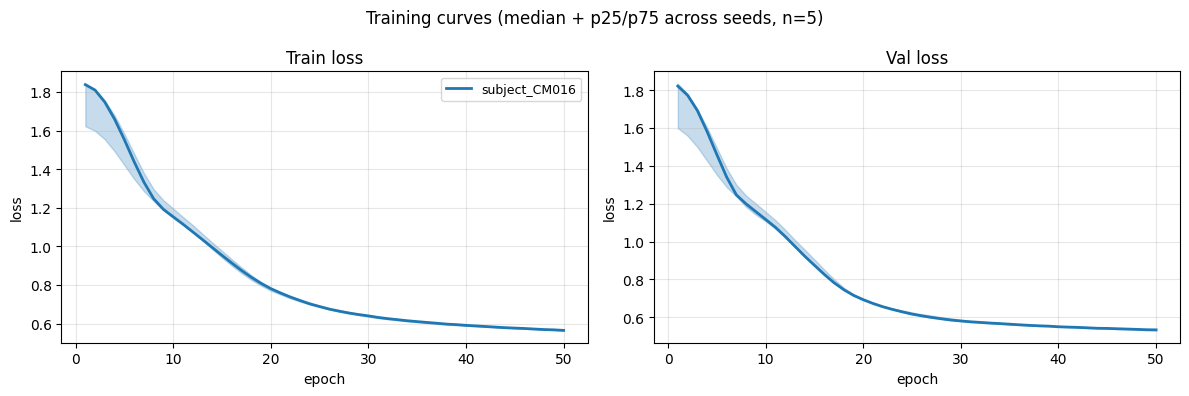

  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/acq_sanity.png


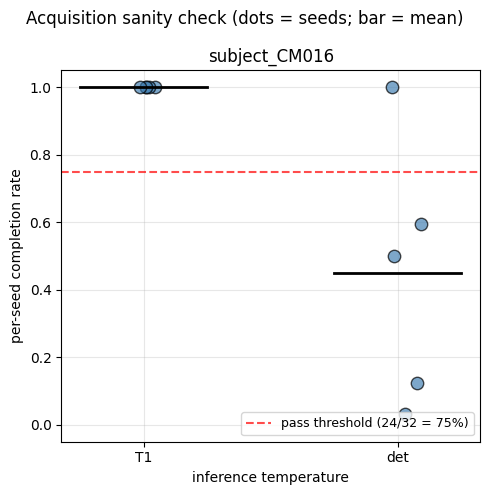

  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/probe_performance.png


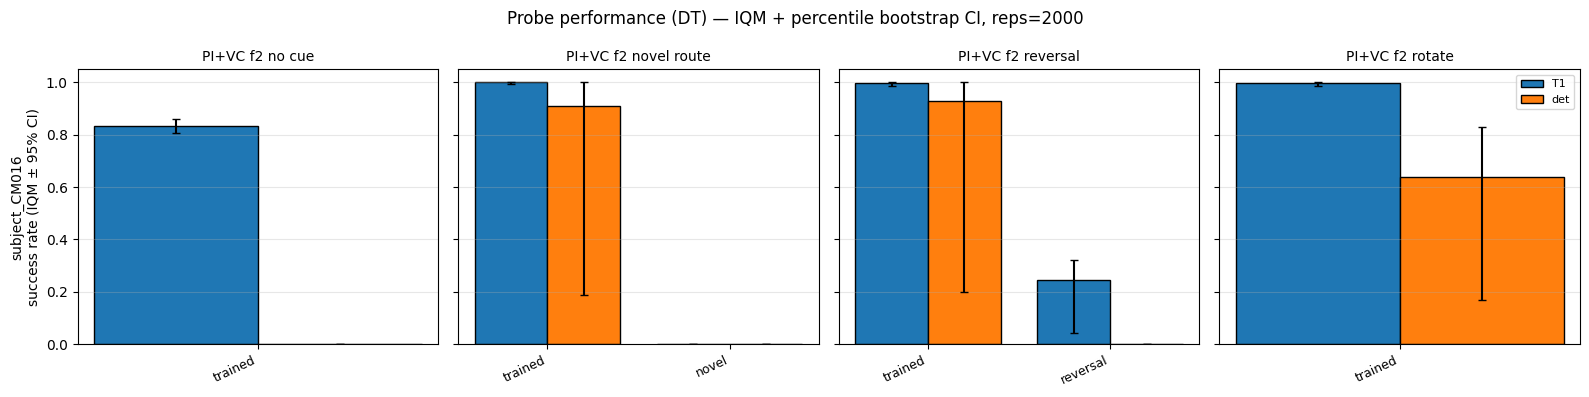

  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/performance_profiles.png


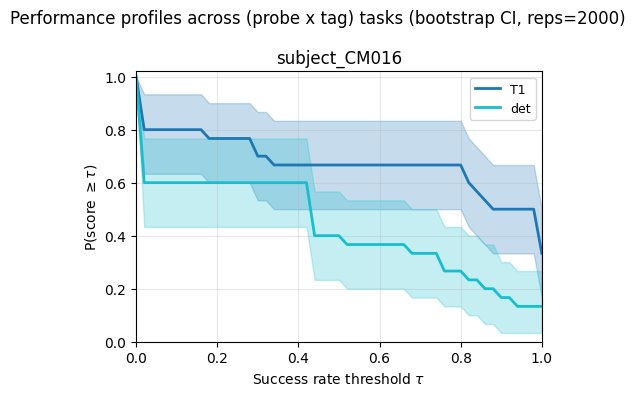

In [16]:
import matplotlib.pyplot as plt

FIGURES_DIR = RUN_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)


# ── numpy replacements for rliable (avoids pandas-3 / arch / statsmodels conflict) ──
def _iqm(arr: np.ndarray) -> float:
    """Interquartile mean: mean of values within [Q1, Q3]."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return float('nan')
    if len(arr) == 1:
        return float(arr[0])
    q1, q3 = np.quantile(arr, [0.25, 0.75])
    keep = arr[(arr >= q1) & (arr <= q3)]
    return float(keep.mean()) if len(keep) else float(arr.mean())


def _iqm_ci(per_seed_scores: np.ndarray, reps: int = 2000,
            seed: int = 0) -> tuple[float, float, float]:
    """IQM + 95% percentile-bootstrap CI from a per-seed score array."""
    arr = np.asarray(per_seed_scores, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return float('nan'), float('nan'), float('nan')
    if len(arr) == 1:
        v = float(arr[0])
        return v, v, v
    rng     = np.random.default_rng(seed)
    n       = len(arr)
    samples = rng.integers(0, n, size=(reps, n))
    boots   = np.array([_iqm(arr[idx]) for idx in samples])
    lo, hi  = np.percentile(boots, [2.5, 97.5])
    return _iqm(arr), float(lo), float(hi)


def _perf_profile(scores_matrix: np.ndarray, tau: np.ndarray,
                  reps: int = 2000, seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Performance profile P(score >= tau) over (seeds × tasks) cells.

    Returns (point, ci) where:
      point: shape (len(tau),)
      ci:    shape (2, len(tau)) — [lo, hi] at 95%
    """
    arr = np.asarray(scores_matrix, dtype=float)
    arr = np.nan_to_num(arr, nan=np.nanmean(arr) if np.any(~np.isnan(arr)) else 0.0)
    flat = arr.reshape(-1)
    point = np.array([(flat >= t).mean() for t in tau])

    rng = np.random.default_rng(seed)
    n   = len(flat)
    boots = np.empty((reps, len(tau)))
    for r in range(reps):
        idx        = rng.integers(0, n, size=n)
        resampled  = flat[idx]
        boots[r]   = [(resampled >= t).mean() for t in tau]
    ci = np.percentile(boots, [2.5, 97.5], axis=0)
    return point, ci


def plot_training_curves(run_root: Path | None = None, show: bool = True):
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    curves_paths = sorted(run_root.glob('*/seed_*/curves.parquet'))
    if not curves_paths:
        print('no curves.parquet — skipping plot_training_curves')
        return
    all_curves = pd.concat([pd.read_parquet(p) for p in curves_paths], ignore_index=True)

    units = sorted(all_curves['unit_label'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(units), 1)))

    for unit, color in zip(units, colors):
        sub = all_curves[all_curves['unit_label'] == unit]
        for ax, col, title in zip(axes, ['train_loss', 'val_loss'], ['Train loss', 'Val loss']):
            stats = (sub.groupby('epoch')[col]
                     .agg(median='median',
                          p25=lambda x: x.quantile(0.25),
                          p75=lambda x: x.quantile(0.75))
                     .reset_index())
            ax.plot(stats['epoch'], stats['median'], color=color, label=unit, lw=2)
            ax.fill_between(stats['epoch'], stats['p25'], stats['p75'], alpha=0.25, color=color)
            ax.set_title(title); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
            ax.grid(True, alpha=0.3)
    axes[0].legend(loc='upper right', fontsize=9)
    fig.suptitle(f'Training curves (median + p25/p75 across seeds, n={all_curves["seed"].nunique()})')
    fig.tight_layout()
    out = FIGURES_DIR / 'training_curves.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def plot_acq_sanity(run_root: Path | None = None, show: bool = True):
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    acq_paths = sorted(run_root.glob('*/seed_*/acq_inference.parquet'))
    if not acq_paths:
        print('no acq_inference.parquet — skipping plot_acq_sanity')
        return
    all_acq = pd.concat([pd.read_parquet(p) for p in acq_paths], ignore_index=True)
    per_seed = (all_acq.groupby(['unit_label', 'temp_label', 'seed'])
                .agg(n_completed=('dt_completed', 'sum'),
                     n_trials=('dt_completed', 'count'))
                .reset_index())
    per_seed['rate'] = per_seed['n_completed'] / per_seed['n_trials']

    units = sorted(per_seed['unit_label'].unique())
    temps = sorted(per_seed['temp_label'].unique())
    n_units = len(units)
    fig, axes = plt.subplots(1, n_units, figsize=(max(4 * n_units, 5), 5), sharey=True)
    if n_units == 1: axes = [axes]
    pass_rate = ACQ_PASS_COMPLETED_TRIALS / ACQ_INFERENCE_TRIALS
    rng = np.random.RandomState(0)
    for ax, unit in zip(axes, units):
        sub = per_seed[per_seed['unit_label'] == unit]
        for i, temp in enumerate(temps):
            rates = sub[sub['temp_label'] == temp]['rate'].values
            jitter = rng.uniform(-0.1, 0.1, size=len(rates))
            ax.scatter(np.full(len(rates), i) + jitter, rates,
                       s=80, alpha=0.7, color='steelblue', edgecolors='black', zorder=3)
            if len(rates):
                ax.plot([i - 0.25, i + 0.25], [rates.mean(), rates.mean()],
                        color='black', lw=2, zorder=4)
        ax.axhline(pass_rate, color='red', linestyle='--', alpha=0.7, zorder=2,
                   label=f'pass threshold ({ACQ_PASS_COMPLETED_TRIALS}/{ACQ_INFERENCE_TRIALS} = {pass_rate:.0%})')
        ax.set_xticks(range(len(temps))); ax.set_xticklabels(temps)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('inference temperature')
        ax.set_title(unit)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('per-seed completion rate')
    axes[0].legend(loc='lower right', fontsize=9)
    fig.suptitle('Acquisition sanity check (dots = seeds; bar = mean)')
    fig.tight_layout()
    out = FIGURES_DIR / 'acq_sanity.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def _per_seed_probe_scores(run_root: Path) -> pd.DataFrame:
    paths = sorted(run_root.glob('*/seed_*/probes.parquet'))
    if not paths:
        return pd.DataFrame()
    all_probes = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    per_seed = (all_probes.groupby(['unit_label', 'probe_session_type', 'trial_tag', 'temp_label', 'seed'])
                .agg(n_trials=('dt_completed', 'count'),
                     n_completed=('dt_completed', 'sum'))
                .reset_index())
    per_seed['rate'] = per_seed['n_completed'] / per_seed['n_trials']
    return per_seed


def plot_probe_performance(run_root: Path | None = None, show: bool = True, bootstrap_reps: int = 2000):
    """Grouped bars per (probe × tag × temp); heights = IQM, error bars = 95% percentile bootstrap CI."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    per_seed = _per_seed_probe_scores(run_root)
    if per_seed.empty:
        print('no probes.parquet — skipping plot_probe_performance')
        return

    units     = sorted(per_seed['unit_label'].unique())
    probes    = sorted(per_seed['probe_session_type'].unique())
    temps     = sorted(per_seed['temp_label'].unique())
    tag_order = ['trained', 'probe_trained', 'novel', 'reversal']

    n_units, n_probes = len(units), len(probes)
    fig, axes = plt.subplots(n_units, n_probes,
                             figsize=(max(4 * n_probes, 6), max(3.8 * n_units, 4)),
                             sharey=True, squeeze=False)

    for ui, unit in enumerate(units):
        for pi, probe in enumerate(probes):
            ax = axes[ui, pi]
            cell = per_seed[(per_seed['unit_label'] == unit) &
                            (per_seed['probe_session_type'] == probe)]
            tags_here = [t for t in tag_order if t in cell['trial_tag'].unique()]
            tags_here.extend(sorted(t for t in cell['trial_tag'].unique() if t not in tag_order))
            x = np.arange(len(tags_here))
            n_temps = len(temps)
            width = 0.8 / max(n_temps, 1)

            for i, temp in enumerate(temps):
                pts, los, his = [], [], []
                for tag in tags_here:
                    scores = cell[(cell['temp_label'] == temp) &
                                  (cell['trial_tag'] == tag)]['rate'].values
                    iqm, lo, hi = _iqm_ci(scores, reps=bootstrap_reps)
                    pts.append(iqm); los.append(lo); his.append(hi)
                pts, los, his = np.array(pts), np.array(los), np.array(his)
                errs = np.array([np.maximum(pts - los, 0), np.maximum(his - pts, 0)])
                offset = (i - (n_temps - 1) / 2) * width
                ax.bar(x + offset, pts, width, label=temp, yerr=errs, capsize=3, edgecolor='black')
            ax.set_xticks(x); ax.set_xticklabels(tags_here, rotation=25, ha='right', fontsize=9)
            ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3, axis='y')
            if ui == 0:
                ax.set_title(probe, fontsize=10)
            if pi == 0:
                ax.set_ylabel(f'{unit}\nsuccess rate (IQM ± 95% CI)')
            if ui == 0 and pi == n_probes - 1:
                ax.legend(loc='upper right', fontsize=8)
    fig.suptitle(f'Probe performance (DT) — IQM + percentile bootstrap CI, reps={bootstrap_reps}')
    fig.tight_layout()
    out = FIGURES_DIR / 'probe_performance.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def plot_performance_profiles(run_root: Path | None = None, show: bool = True, reps: int = 2000):
    """P(success_rate >= tau) across all (probe x tag) tasks, one curve per temp."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    per_seed = _per_seed_probe_scores(run_root)
    if per_seed.empty:
        print('no probes.parquet — skipping plot_performance_profiles')
        return

    units = sorted(per_seed['unit_label'].unique())
    temps = sorted(per_seed['temp_label'].unique())
    tau   = np.linspace(0.0, 1.0, 51)

    fig, axes = plt.subplots(1, len(units), figsize=(max(5 * len(units), 5), 4), sharey=True, squeeze=False)
    axes = axes[0]
    palette = dict(zip(temps, plt.cm.tab10(np.linspace(0, 1, len(temps)))))
    for ax, unit in zip(axes, units):
        sub   = per_seed[per_seed['unit_label'] == unit]
        tasks = sorted({(p, t) for p, t in zip(sub['probe_session_type'], sub['trial_tag'])})
        seeds = sorted(sub['seed'].unique())
        for temp in temps:
            arr = np.full((len(seeds), len(tasks)), np.nan)
            for r, sd in enumerate(seeds):
                for c, (p, t) in enumerate(tasks):
                    cell = sub[(sub['temp_label'] == temp) & (sub['seed'] == sd)
                               & (sub['probe_session_type'] == p) & (sub['trial_tag'] == t)]
                    if len(cell):
                        arr[r, c] = float(cell['rate'].iloc[0])
            pt, ci = _perf_profile(arr, tau, reps=reps)
            color = palette[temp]
            ax.plot(tau, pt, color=color, label=temp, lw=2)
            ax.fill_between(tau, ci[0], ci[1], color=color, alpha=0.25)
        ax.set_title(unit); ax.grid(True, alpha=0.3)
        ax.set_xlabel(r'Success rate threshold $\tau$')
        ax.set_ylabel(r'P(score $\geq\tau$)')
        ax.set_ylim(0, 1.02); ax.set_xlim(0, 1)
        ax.legend(loc='upper right', fontsize=9)

    fig.suptitle(f'Performance profiles across (probe x tag) tasks (bootstrap CI, reps={reps})')
    fig.tight_layout()
    out = FIGURES_DIR / 'performance_profiles.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


# Auto-execute
print(f'=== plotting -> {FIGURES_DIR} ===')
plot_training_curves()
plot_acq_sanity()
plot_probe_performance()
plot_performance_profiles()


## 13. DT diagnostics — paths + attention

Drill-down visualizations that go beyond Cell 12's aggregates. Three plots, auto-execute:

1. **Path replay** (`path_replay.png`) — one DT trial on the 13×13 maze. Default: first completed trial of seed 0's first probe paradigm, deterministic. Trajectory line colored by step (viridis), markers at start (green) / end (red), wells (open squares). For per-(probe, trial) drill-down, call `plot_path_replay(probe=..., trial_idx=...)` manually.

2. **Attention by step-offset, split by modality** (`attention_summary.png`) — for each saved probe's deterministic attention file, decode each attention column into `(step_offset, modality)` where `step_offset ∈ [-(K-1), 0]` and `modality ∈ {R, s, a}`. Average over steps and heads, plot three lines (R / s / a) showing average attention vs how far back. The headline question: which modality stream does the DT lean on most, and across what horizon?

3. **Attention head × step-offset heatmap** (`attention_heatmap.png`) — same data, but kept per-head. One subplot per (probe × modality) showing all `n_heads` rows. Reveals whether different heads specialize on different temporal scales or modalities.

**Why only deterministic attention?** Cell 9 only saves attention for deterministic rollouts (per Cell 1's `SAVE_PROBE_ATTENTION` + Cell 9's `save_attn = save_attention and is_det` rule). Sampled rollouts have rollout-specific noise that makes per-step attention less interpretable.

**Inputs**: reads `RUN_ROOT/*/seed_*/probe_trajectory.parquet` and `RUN_ROOT/*/seed_*/attention/probe_*.pt`. All saved by Cell 9.

**Useful follow-ups**: per-cohort comparison (PI vs PI+VC vs VC) when multiple subject groups exist — would just loop these plots over units. Not in v1, easy to add.

=== DT diagnostics → /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures ===
  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/path_replay.png


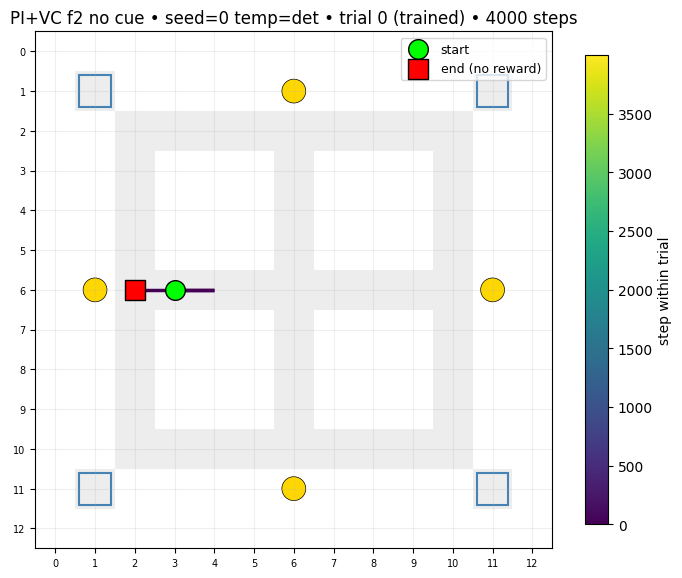

  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/attention_summary.png


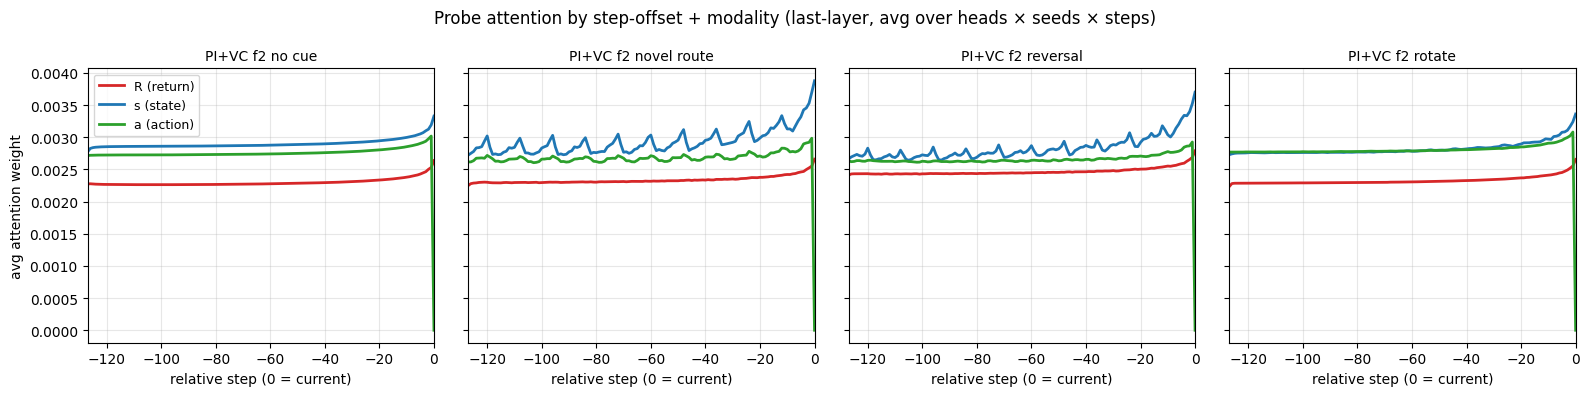

  wrote /home/rianbutala/projects/corner-maze-rl/data/runs/dt-vanilla-pi-cm016-bf16_20260528_013632/figures/attention_heatmap.png


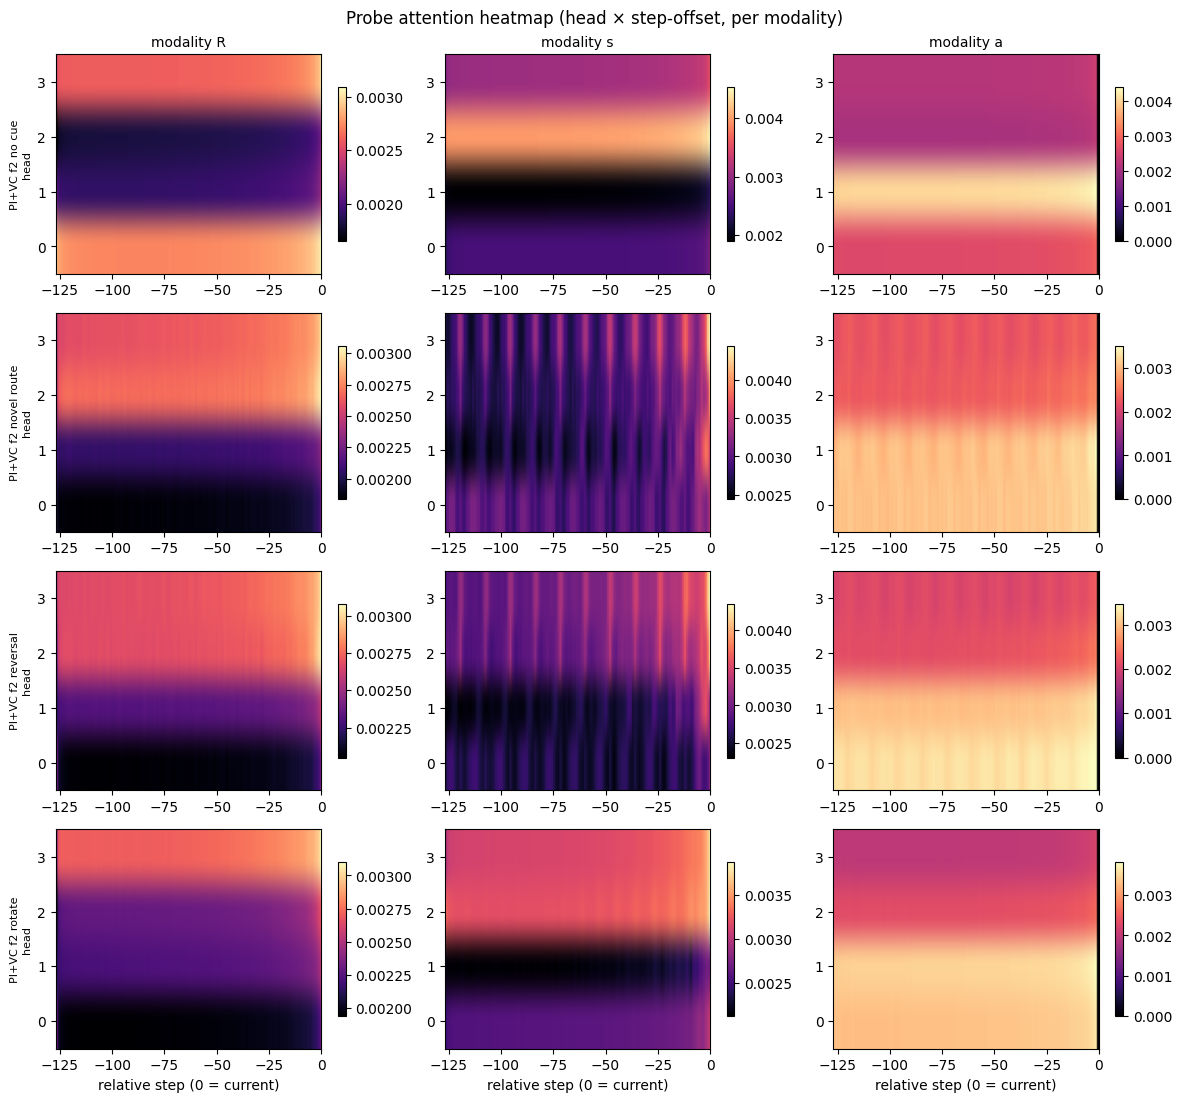

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from corner_maze_rl.env.constants import WELL_LOCATIONS, CUE_LOCATIONS

# ── Maze layout helper ──────────────────────────────────
def _draw_maze_skeleton(ax):
    """Draw the 13×13 maze skeleton (valid floor cells, wells, cues)."""
    # Valid floor cells: 3 horizontal corridors (y=2,6,10) and 4 arms
    valid = set()
    for j in range(9):
        for ay in (2, 6, 10):
            valid.add((j + 2, ay))
    for ax_off in (2, 6, 10):
        for j in range(3):
            valid.add((ax_off, j + 3))
            valid.add((ax_off, j + 7))
    # The four well corners
    for wx, wy in WELL_LOCATIONS:
        valid.add((wx, wy))
    # Plot floor as light cells
    for (x, y) in valid:
        ax.add_patch(mpatches.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                         facecolor='lightgray', alpha=0.4, edgecolor='none'))
    # Wells
    for wx, wy in WELL_LOCATIONS:
        ax.add_patch(mpatches.Rectangle((wx - 0.4, wy - 0.4), 0.8, 0.8,
                                         facecolor='none', edgecolor='steelblue', lw=1.5))
    # Cues (the four cardinal cue display positions)
    for cx, cy in CUE_LOCATIONS:
        ax.add_patch(mpatches.Circle((cx, cy), 0.3, facecolor='gold', edgecolor='black', lw=0.5))
    ax.set_xlim(-0.5, 12.5); ax.set_ylim(12.5, -0.5)  # y-down for screen coords
    ax.set_aspect('equal')
    ax.set_xticks(range(13)); ax.set_yticks(range(13))
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)


# ── Path replay ─────────────────────────────────────────
def plot_path_replay(run_root: Path | None = None,
                     probe: str | None = None,
                     temp_label: str = 'det',
                     seed: int | None = None,
                     trial_idx: int | None = None,
                     show: bool = True):
    """Plot one trial's grid trajectory. Defaults pick the first completed (or first) trial."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    paths = sorted(run_root.glob('*/seed_*/probe_trajectory.parquet'))
    if not paths:
        print('no probe_trajectory.parquet — skipping plot_path_replay')
        return
    traj = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)

    if seed is None:       seed       = int(traj['seed'].min())
    if probe is None:      probe      = sorted(traj['probe_session_type'].unique())[0]
    # Filter to (seed, probe, temp, repeat_idx=0)
    sub = traj[(traj['seed'] == seed) & (traj['probe_session_type'] == probe)
               & (traj['temp_label'] == temp_label) & (traj['repeat_idx'] == 0)]
    if sub.empty:
        print(f'no trajectory for seed={seed} probe={probe!r} temp={temp_label!r} — skipping')
        return
    # Pick the trial: first completed, else first
    if trial_idx is None:
        completed_trials = sub[sub['env_reward'] > 0.5]['trial_id'].unique()
        trial_idx = int(completed_trials[0]) if len(completed_trials) else int(sub['trial_id'].min())
    trial = sub[sub['trial_id'] == trial_idx].sort_values('step').reset_index(drop=True)
    if trial.empty:
        print(f'no trial_id={trial_idx} — skipping')
        return

    fig, ax = plt.subplots(figsize=(7, 7))
    _draw_maze_skeleton(ax)

    xs, ys = trial['grid_x'].values, trial['grid_y'].values
    # Color trajectory by step (viridis)
    segs = np.array([[xs[:-1], ys[:-1]], [xs[1:], ys[1:]]]).transpose(2, 0, 1)
    lc = LineCollection(segs, cmap='viridis', linewidths=2.5)
    lc.set_array(np.arange(len(xs) - 1))
    ax.add_collection(lc)
    plt.colorbar(lc, ax=ax, shrink=0.7, label='step within trial')
    # Start (green) and end (red)
    ax.scatter([xs[0]], [ys[0]], s=200, c='lime', edgecolors='black', zorder=5, label='start')
    ax.scatter([xs[-1]], [ys[-1]], s=200, c='red', edgecolors='black', zorder=5,
               marker='X' if (trial['env_reward'].iloc[-1] > 0.5) else 's',
               label='reward' if (trial['env_reward'].iloc[-1] > 0.5) else 'end (no reward)')
    ax.legend(loc='upper right', fontsize=9)
    tag = trial['trial_tag'].iloc[0]
    ax.set_title(f'{probe} • seed={seed} temp={temp_label} • trial {trial_idx} ({tag}) • '
                 f'{len(trial)} steps')
    fig.tight_layout()
    out = FIGURES_DIR / 'path_replay.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


# ── Attention aggregation ───────────────────────────────
def _load_probe_attention_files(run_root: Path) -> list[dict]:
    """Load all saved probe attention .pt files. Returns list of dicts."""
    out = []
    for p in sorted(run_root.glob('*/seed_*/attention/probe_*.pt')):
        try:
            data = torch.load(p, weights_only=False)
            data['_path'] = p
            out.append(data)
        except Exception as e:
            print(f'  [warn] failed to load {p}: {e}')
    return out


def _decode_attention_to_modality_grid(saved: dict) -> np.ndarray | None:
    """From a saved attention dict, return a (n_heads, K, 3) array averaged over steps.

    The saved 'episode_attention' is a list (per env step) of (n_heads, ctx_K * 3) tensors.
    Each column j is at relative step_offset = (j // 3) - (ctx_K - 1), modality = j % 3.
    We aggregate over time by averaging across all per-step rows, binning by (offset, modality).
    Modality index: 0=R, 1=s, 2=a.
    Returns array of shape (n_heads, K, 3) where K = (max step_offset range) = full K context.
    """
    ep_attn = saved.get('episode_attention', [])
    if not ep_attn:
        return None
    n_heads = ep_attn[0].shape[0]
    # Aggregate
    sum_grid = np.zeros((n_heads, K, 3), dtype=np.float64)
    cnt_grid = np.zeros((n_heads, K, 3), dtype=np.int64)
    for step_attn in ep_attn:
        arr = step_attn.numpy() if hasattr(step_attn, 'numpy') else np.asarray(step_attn)
        ctx_len = arr.shape[1] // 3
        for j in range(arr.shape[1]):
            offset = (j // 3) - (ctx_len - 1)   # in [-(ctx_len-1), 0]
            modality = j % 3
            offset_idx = offset + (K - 1)        # remap to [0, K-1]
            if 0 <= offset_idx < K:
                sum_grid[:, offset_idx, modality] += arr[:, j]
                cnt_grid[:, offset_idx, modality] += 1
    with np.errstate(invalid='ignore'):
        mean_grid = np.where(cnt_grid > 0, sum_grid / np.maximum(cnt_grid, 1), 0.0)
    return mean_grid


def plot_attention_summary(run_root: Path | None = None, show: bool = True):
    """Per-probe: avg attention by step_offset, split by modality (R/s/a). Averaged over heads."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    attns = _load_probe_attention_files(run_root)
    if not attns:
        print('no probe attention .pt files — skipping plot_attention_summary')
        return

    # Group by probe; average across all (seed × probe attention files)
    probes = sorted({d['probe_session_type'] for d in attns})
    fig, axes = plt.subplots(1, len(probes), figsize=(max(4 * len(probes), 6), 4),
                              sharey=True, squeeze=False)
    axes = axes[0]
    offsets = np.arange(-(K - 1), 1)
    mod_names = ['R (return)', 's (state)', 'a (action)']
    mod_colors = ['tab:red', 'tab:blue', 'tab:green']

    for ax, probe in zip(axes, probes):
        grids = [g for d in attns if d['probe_session_type'] == probe
                 and (g := _decode_attention_to_modality_grid(d)) is not None]
        if not grids:
            ax.set_title(f'{probe}\n(no attention data)')
            continue
        # Average over (files × heads): (K, 3)
        avg = np.stack(grids).mean(axis=0).mean(axis=0)
        for m in range(3):
            ax.plot(offsets, avg[:, m], color=mod_colors[m], lw=2, label=mod_names[m])
        ax.set_xlabel('relative step (0 = current)')
        ax.set_xlim(-(K - 1), 0)
        ax.set_title(probe, fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('avg attention weight')
    axes[0].legend(loc='upper left', fontsize=9)
    fig.suptitle(f'Probe attention by step-offset + modality (last-layer, avg over heads × seeds × steps)')
    fig.tight_layout()
    out = FIGURES_DIR / 'attention_summary.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def plot_attention_heatmap(run_root: Path | None = None, show: bool = True):
    """Per-(probe × modality): head × step_offset heatmap (averaged over files + steps)."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    attns = _load_probe_attention_files(run_root)
    if not attns:
        print('no probe attention .pt files — skipping plot_attention_heatmap')
        return

    probes = sorted({d['probe_session_type'] for d in attns})
    mod_names = ['R', 's', 'a']
    fig, axes = plt.subplots(len(probes), 3, figsize=(12, max(2.8 * len(probes), 4)),
                              squeeze=False)
    offsets = np.arange(-(K - 1), 1)

    for ri, probe in enumerate(probes):
        grids = [g for d in attns if d['probe_session_type'] == probe
                 and (g := _decode_attention_to_modality_grid(d)) is not None]
        if not grids:
            for ci in range(3):
                axes[ri, ci].axis('off')
            continue
        avg = np.stack(grids).mean(axis=0)   # (n_heads, K, 3)
        n_heads = avg.shape[0]
        for ci in range(3):
            ax = axes[ri, ci]
            im = ax.imshow(avg[:, :, ci], aspect='auto', origin='lower',
                            extent=[offsets[0], offsets[-1], -0.5, n_heads - 0.5],
                            cmap='magma')
            ax.set_yticks(range(n_heads))
            if ci == 0:
                ax.set_ylabel(f'{probe}\nhead', fontsize=8)
            if ri == 0:
                ax.set_title(f'modality {mod_names[ci]}', fontsize=10)
            if ri == len(probes) - 1:
                ax.set_xlabel('relative step (0 = current)')
            plt.colorbar(im, ax=ax, shrink=0.7)
    fig.suptitle('Probe attention heatmap (head × step-offset, per modality)')
    fig.tight_layout()
    out = FIGURES_DIR / 'attention_heatmap.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


# ── Auto-execute ──────────────────────────────────────────
print(f'=== DT diagnostics → {FIGURES_DIR} ===')
plot_path_replay()
plot_attention_summary()
plot_attention_heatmap()


## 14. Session playback (animate one inference trial)

`playback_trial(...)` reconstructs one DT inference trial into an animated GIF — like `02_explore_yoked_data.ipynb`'s replay but for the DT's behavior on probes (or acquisition). Useful for: "why did this rollout fail?" / "what was the agent doing on step 47?" / "how does sampled DT differ from argmax DT on the same trial conditions?"

**Each frame shows**:
- Left panel: 13×13 maze skeleton (floor cells, wells, cues) with the agent's path so far (blue line, growing) + current position (red dot) + start position (green dot).
- Right panel: per-step monospace info — action being taken, env reward this step, model's `rtg_before_action`, trial id/tag/timestep, and the canonical pose_label.

**Defaults**: first completed trial of first seed's first probe paradigm at deterministic temp. Override via kwargs for drill-down:
```python
playback_trial(probe='PI+VC f2 novel route', seed=2, temp_label='T1', trial_idx=15)
playback_trial(source='acq', trial_idx=8)            # acquisition trial
```

**Output**: GIF saved to `RUN_ROOT/figures/playback_*.gif`, displayed inline.

**Cost**: ~3-10 sec per trial to generate (depends on `fps` and trial length). Default `fps=8` gives a watchable ~5 sec animation for a ~40-step trial.

**Requires**: `*_trajectory.parquet` files (from Cell 10). If you haven't run the full pipeline yet, this cell prints a "no data" notice and does nothing.

In [14]:
import asyncio
import io
import json

import ipywidgets as widgets
from PIL import Image as PILImage
from IPython.display import display

from corner_maze_rl.env.constants import EYE_IMG_SIZE


# ── Theme + sizing ────────────────────────────────────────
BG_COLOR    = "#333333"
TEXT_COLOR  = "#ffffff"
MUTED_COLOR = "#aaaaaa"
IMG_SIZE    = 299              # 13 * 23
FIELD_W     = "320px"
ACTION_NAMES = {0: 'Left', 1: 'Right', 2: 'Forward', 3: 'Enter Well', 4: 'Pause'}

style_widget = widgets.HTML(f"""<style>
.dt-ui, .dt-ui * {{
    background-color: {BG_COLOR} !important;
    color: {TEXT_COLOR} !important;
    border-color: {BG_COLOR} !important;
}}
.dt-ui {{ padding: 15px !important; }}
.dt-ui .widget-image {{ background-color: transparent !important; }}
.dt-ui .form-input select,
.dt-ui .form-input input {{
    background-color: #4a4a4a !important;
    color: #ffffff !important;
    border: 1px solid #888 !important;
    border-radius: 4px !important;
    padding: 2px 6px !important;
}}
.dt-ui .form-button,
.dt-ui .form-button > button {{
    background: #6a6a6a !important;
    background-color: #6a6a6a !important;
    color: #ffffff !important;
    border: 1px solid #d0d0d0 !important;
    border-radius: 4px !important;
    box-shadow: inset 0 0 0 1px #d0d0d0 !important;
    font-weight: 500 !important;
    padding: 4px 12px !important;
}}
.dt-ui .form-field-label {{
    font-size: 12px !important;
    font-weight: 600 !important;
    color: #c8c8c8 !important;
    margin: 6px 0 2px 0 !important;
}}
.dt-ui .form-status {{
    font-size: 12px !important;
    color: #c8c8c8 !important;
    margin: 8px 0 0 0 !important;
    line-height: 1.5 !important;
}}
.dt-ui select option {{ background-color: #4a4a4a !important; color: #ffffff !important; }}
</style>""")


# ── Image helpers ─────────────────────────────────────────
zero_eye   = np.zeros((EYE_IMG_SIZE, EYE_IMG_SIZE), dtype=np.float64)
blank_maze = np.full((23 * 13, 23 * 13, 3), 30, dtype=np.uint8)

def _frame_to_png(frame):
    img = PILImage.fromarray(frame).resize((IMG_SIZE, IMG_SIZE), PILImage.NEAREST)
    buf = io.BytesIO(); img.save(buf, format="PNG"); return buf.getvalue()

def _eye_to_png(eye_arr):
    gray = (np.asarray(eye_arr, dtype=np.float64) * 255).astype(np.uint8)
    img  = PILImage.fromarray(gray).resize((IMG_SIZE, IMG_SIZE), PILImage.NEAREST)
    buf  = io.BytesIO(); img.save(buf, format="PNG"); return buf.getvalue()


# ── Load all DT trajectories from RUN_ROOT ────────────────
def _load_dt_trajectories(run_root: Path) -> pd.DataFrame:
    frames = []
    for fname in ('acq_trajectory.parquet', 'probe_trajectory.parquet'):
        for p in sorted(Path(run_root).glob(f'*/seed_*/{fname}')):
            df = pd.read_parquet(p)
            # Normalize session-type column across acq (`paradigm`) and probe (`probe_session_type`).
            if 'paradigm' in df.columns:
                df['_session_type'] = df['paradigm']
            elif 'probe_session_type' in df.columns:
                df['_session_type'] = df['probe_session_type']
            else:
                df['_session_type'] = '(unknown)'
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


TRAJ = _load_dt_trajectories(RUN_ROOT)


if TRAJ.empty:
    print(f'No DT trajectory parquets found under {RUN_ROOT}. Run Cell 10 first.')
else:
    # ── Mutable state shared across callbacks ────────────
    state = {
        'env':          None,
        'actions':      None,
        'n_steps':      0,
        'current_step': 0,
        'has_eyes':     False,
        'seed':         0,
        'label_str':    '(no rollout loaded)',
    }
    play_state = {'running': False}

    # ── Display widgets ──────────────────────────────────
    maze_widget      = widgets.Image(format='png', width=IMG_SIZE, height=IMG_SIZE,
                                     value=_frame_to_png(blank_maze))
    left_eye_widget  = widgets.Image(format='png', width=IMG_SIZE, height=IMG_SIZE,
                                     value=_eye_to_png(zero_eye))
    right_eye_widget = widgets.Image(format='png', width=IMG_SIZE, height=IMG_SIZE,
                                     value=_eye_to_png(zero_eye))
    label_widget     = widgets.HTML(value='')
    info_widget      = widgets.HTML(value='')
    status_label     = widgets.HTML(value='')
    status_label.add_class('form-status')

    def _render():
        env = state['env']
        if env is not None:
            maze_widget.value = _frame_to_png(env.get_allocentric_frame(tile_size=23))
            if state['has_eyes']:
                try:
                    pose = env.get_pose_label()
                    le   = env._pose_to_left_eye.get(pose, zero_eye)
                    re   = env._pose_to_right_eye.get(pose, zero_eye)
                except Exception:
                    le = re = zero_eye
            else:
                le = re = zero_eye
            left_eye_widget.value  = _eye_to_png(le)
            right_eye_widget.value = _eye_to_png(re)
        else:
            maze_widget.value      = _frame_to_png(blank_maze)
            left_eye_widget.value  = _eye_to_png(zero_eye)
            right_eye_widget.value = _eye_to_png(zero_eye)
        label_widget.value = (
            f'<div style="font-size:13px; text-align:center; margin-top:4px;">'
            f'<b>{state["label_str"]}</b></div>'
        )

        # Info panel: trial, step, pose, action, session score, RTG
        actions = state['actions']
        if env is not None and actions is not None and state['n_steps'] > 0:
            cs = state['current_step']
            n  = state['n_steps']
            total_trials = int(actions['trial_id'].max()) + 1
            cum_reward   = float(actions.iloc[:cs]['env_reward'].sum()) if cs > 0 else 0.0
            if cs < n:
                row          = actions.iloc[cs]
                trial_num    = int(row['trial_id']) + 1
                pose_str     = str(row['pose_label'])
                act_idx      = int(row['action'])
                action_str   = f"{ACTION_NAMES.get(act_idx, '?')} ({act_idx})"
                rtg_str      = f"{float(row['rtg_before_action']):.4f}"
            else:
                last         = actions.iloc[-1]
                trial_num    = int(last['trial_id']) + 1
                pose_str     = '—'
                action_str   = '— (done)'
                rtg_str      = f"{float(last['rtg_before_action']):.4f}"
            info_widget.value = (
                f'<div style="font-size:13px; line-height:1.7; font-family:monospace; '
                f'text-align:center; margin-top:4px;">'
                f'<b>Trial:</b> {trial_num} / {total_trials} &nbsp; '
                f'<b>Step:</b> {cs} / {n}<br>'
                f'<b>Pose:</b> <code>{pose_str}</code><br>'
                f'<b>Action:</b> {action_str} &nbsp; '
                f'<b>Score:</b> {cum_reward:+.4f} &nbsp; '
                f'<b>RTG:</b> {rtg_str}'
                f'</div>'
            )
        else:
            info_widget.value = (
                f'<div style="font-size:13px; color:{MUTED_COLOR}; '
                f'text-align:center; margin-top:4px;">—</div>'
            )

    # ── Picker dropdowns ─────────────────────────────────
    SOURCES = sorted(TRAJ['source'].unique().tolist())
    source_dd   = widgets.Dropdown(options=SOURCES, value=SOURCES[0],
                                   layout=widgets.Layout(width=FIELD_W))
    paradigm_dd = widgets.Dropdown(options=[], layout=widgets.Layout(width=FIELD_W))
    temp_dd     = widgets.Dropdown(options=[], layout=widgets.Layout(width=FIELD_W))
    seed_dd     = widgets.Dropdown(options=[], layout=widgets.Layout(width=FIELD_W))
    repeat_dd   = widgets.Dropdown(options=[], layout=widgets.Layout(width=FIELD_W))
    for dd in (source_dd, paradigm_dd, temp_dd, seed_dd, repeat_dd):
        dd.add_class('form-input')

    def _filtered() -> pd.DataFrame:
        df = TRAJ[TRAJ['source'] == source_dd.value]
        if paradigm_dd.value is not None:
            df = df[df['_session_type'] == paradigm_dd.value]
        if temp_dd.value is not None:
            df = df[df['temp_label'] == temp_dd.value]
        if seed_dd.value is not None:
            df = df[df['seed'] == seed_dd.value]
        if repeat_dd.value is not None:
            df = df[df['repeat_idx'] == repeat_dd.value]
        return df

    def _refresh_paradigm():
        df   = TRAJ[TRAJ['source'] == source_dd.value]
        opts = sorted(df['_session_type'].unique().tolist())
        paradigm_dd.options = opts
        paradigm_dd.value   = opts[0] if opts else None

    def _refresh_temp():
        df = TRAJ[(TRAJ['source'] == source_dd.value)
                  & (TRAJ['_session_type'] == paradigm_dd.value)]
        opts = sorted(df['temp_label'].unique().tolist())
        temp_dd.options = opts
        temp_dd.value   = opts[0] if opts else None

    def _refresh_seed():
        df = TRAJ[(TRAJ['source'] == source_dd.value)
                  & (TRAJ['_session_type'] == paradigm_dd.value)
                  & (TRAJ['temp_label']    == temp_dd.value)]
        opts = sorted(df['seed'].unique().tolist())
        seed_dd.options = opts
        seed_dd.value   = opts[0] if opts else None

    def _refresh_repeat():
        df = TRAJ[(TRAJ['source'] == source_dd.value)
                  & (TRAJ['_session_type'] == paradigm_dd.value)
                  & (TRAJ['temp_label']    == temp_dd.value)
                  & (TRAJ['seed']          == seed_dd.value)]
        opts = sorted(df['repeat_idx'].unique().tolist())
        repeat_dd.options = opts
        repeat_dd.value   = opts[0] if opts else None

    source_dd.observe(lambda _c: (_refresh_paradigm(), _refresh_temp(),
                                  _refresh_seed(), _refresh_repeat()),  names='value')
    paradigm_dd.observe(lambda _c: (_refresh_temp(), _refresh_seed(),
                                    _refresh_repeat()),                  names='value')
    temp_dd.observe(lambda _c: (_refresh_seed(), _refresh_repeat()),     names='value')
    seed_dd.observe(lambda _c: _refresh_repeat(),                        names='value')

    _refresh_paradigm(); _refresh_temp(); _refresh_seed(); _refresh_repeat()

    # ── Playback controls ────────────────────────────────
    speed_slider = widgets.IntSlider(value=20, min=1, max=120, step=1,
                                     description='Steps/sec', continuous_update=True,
                                     layout=widgets.Layout(width=FIELD_W))
    progress     = widgets.IntProgress(value=0, min=0, max=1,
                                       layout=widgets.Layout(width=FIELD_W))
    run_button     = widgets.Button(description='Run',     layout=widgets.Layout(height='34px', width='120px'))
    reset_button   = widgets.Button(description='Reset',   icon='undo',
                                                            layout=widgets.Layout(height='34px', width='120px'))
    play_button    = widgets.Button(description='▶ Play',  layout=widgets.Layout(height='34px', width='120px'))
    back_button    = widgets.Button(description='← Back',  layout=widgets.Layout(height='34px', width='90px'))
    forward_button = widgets.Button(description='Step →',  layout=widgets.Layout(height='34px', width='90px'))
    for b in (run_button, reset_button, play_button, back_button, forward_button):
        b.add_class('form-button')

    def _set_status(html, color=MUTED_COLOR):
        status_label.value = f'<div style="color:{color};">{html}</div>'

    def _stop_play():
        play_state['running'] = False
        play_button.description = '▶ Play'

    def _advance_one_step() -> bool:
        if state['env'] is None or state['actions'] is None: return False
        if state['current_step'] >= state['n_steps']:        return False
        row = state['actions'].iloc[state['current_step']]
        try:
            _obs, _r, terminated, truncated, _info = state['env'].step(int(row['action']))
        except Exception as exc:
            _set_status(f"env.step failed at step {state['current_step']}: {exc}", color='#f88')
            return False
        state['current_step'] += 1
        # Sanity: env's post-step pose should match the parquet's next pre-action row.
        cs = state['current_step']
        if cs < state['n_steps']:
            r2 = state['actions'].iloc[cs]
            x, y = state['env'].agent_pos
            d    = state['env'].agent_dir
            env_pose    = (int(x), int(y), int(d))
            parquet_pose = (int(r2['grid_x']), int(r2['grid_y']), int(r2['direction']))
            if env_pose != parquet_pose:
                _set_status(
                    f'env diverged from parquet at step {cs}: '
                    f'env={env_pose} vs parquet={parquet_pose}',
                    color='#fa8')
        if terminated or truncated:
            return False
        return True

    def _replay_to(target_step: int):
        env = state['env']
        if env is None or state['actions'] is None: return
        target_step = max(0, min(target_step, state['n_steps']))
        env.reset(seed=state['seed'])
        state['current_step'] = 0
        while state['current_step'] < target_step:
            if not _advance_one_step(): break

    async def _play_loop():
        while play_state['running']:
            advanced = _advance_one_step()
            progress.value = state['current_step']
            _render()
            if not advanced: break
            sps = max(1, int(speed_slider.value))
            await asyncio.sleep(1.0 / sps)
        _stop_play()

    def on_run_click(_b):
        _stop_play()
        df = _filtered()
        if df.empty:
            _set_status('No rows for that selection.', color='#f88'); return
        actions = df.sort_values('step').reset_index(drop=True)
        subject      = str(actions['subject'].iloc[0])
        session_type = str(actions['_session_type'].iloc[0])
        rep_seed     = int(actions['rep_seed'].iloc[0])
        unit_label   = str(actions['unit_label'].iloc[0])
        seed_val     = int(actions['seed'].iloc[0])
        repeat_idx   = int(actions['repeat_idx'].iloc[0])
        temp_label_v = str(actions['temp_label'].iloc[0])

        if subject not in _SUBJECT_META:
            _set_status(f'No subject metadata for {subject!r}.', color='#f88'); return
        cgo = _SUBJECT_META[subject]['cue_goal_orientation']
        sgl = _trained_goal_for_subject(subject)

        # Load trial_configs sidecar so env reproduces inference's actual trial pool
        # (gen_grid_configuration_sequence uses stdlib random, so seed alone isn't enough).
        src_name = source_dd.value
        sidecar_name = 'acq_trial_configs.json' if src_name == 'acq' else 'probes_trial_configs.json'
        sidecar_path = Path(RUN_ROOT) / unit_label / f'seed_{seed_val}' / sidecar_name
        trial_configs = None
        if sidecar_path.is_file():
            with open(sidecar_path) as _f:
                configs_map = json.load(_f)
            key = (f'{temp_label_v}__{repeat_idx}' if src_name == 'acq'
                   else f'{session_type}__{temp_label_v}__{repeat_idx}')
            trial_configs = configs_map.get(key)
            if trial_configs is None:
                _set_status(f'No trial_configs entry for key {key!r} in {sidecar_path.name}.', color='#fa8')
        else:
            _set_status(f'No {sidecar_name} found — env may diverge. Re-run Cell 10.', color='#fa8')

        try:
            env = CornerMazeEnv(
                max_steps=max(10000, len(actions) + 100),
                session_type=session_type,
                agent_cue_goal_orientation=cgo,
                start_goal_location=sgl,
                obs_mode='view',
                render_mode='rgb_array',
                trial_configs=trial_configs,
            )
            env.reset(seed=rep_seed)
        except Exception as exc:
            _set_status(f'Could not build env: {type(exc).__name__}: {exc}', color='#f88'); return

        has_eyes = False
        try:
            env._load_embeddings(); has_eyes = True
        except Exception:
            pass

        state['env']          = env
        state['actions']      = actions
        state['n_steps']      = len(actions)
        state['current_step'] = 0
        state['has_eyes']     = has_eyes
        state['seed']         = rep_seed
        state['label_str']    = (
            f'{subject} · {source_dd.value} · {session_type} · '
            f'seed={int(actions["seed"].iloc[0])}  {temp_dd.value}  rep={int(actions["repeat_idx"].iloc[0])}'
        )
        progress.value = 0
        progress.max   = max(1, state['n_steps'])
        _set_status(f'Loaded {state["n_steps"]:,} steps. Press Play.')
        _render()

    def on_play_click(_b):
        if state['env'] is None:
            _set_status('Run a rollout first.', color='#f88'); return
        if play_state['running']:
            _stop_play(); return
        if state['current_step'] >= state['n_steps']:
            on_reset_click(None)
        play_state['running'] = True
        play_button.description = '⏸ Pause'
        asyncio.ensure_future(_play_loop())

    def on_forward_click(_b):
        if state['env'] is None:
            _set_status('Run a rollout first.', color='#f88'); return
        _stop_play()
        _advance_one_step()
        progress.value = state['current_step']
        _render()

    def on_back_click(_b):
        if state['env'] is None:
            _set_status('Run a rollout first.', color='#f88'); return
        _stop_play()
        if state['current_step'] == 0: return
        target = state['current_step'] - 1
        if target > 200:
            _set_status(f'Rewinding to step {target}…')
        _replay_to(target)
        progress.value = state['current_step']
        _set_status(f'At step {state["current_step"]}.')
        _render()

    def on_reset_click(_b):
        if state['env'] is None: return
        _stop_play()
        state['env'].reset(seed=state['seed'])
        state['current_step'] = 0
        progress.value = 0
        _set_status('Reset to step 0.')
        _render()

    run_button.on_click(on_run_click)
    reset_button.on_click(on_reset_click)
    play_button.on_click(on_play_click)
    back_button.on_click(on_back_click)
    forward_button.on_click(on_forward_click)

    # ── Layout ──────────────────────────────────────────
    col_style = widgets.Layout(width=f'{IMG_SIZE}px', align_items='center')
    maze_col  = widgets.VBox([widgets.HTML('<b>Maze</b>'), maze_widget, label_widget],
                             layout=col_style)
    le_col    = widgets.VBox([widgets.HTML('<b>Left Eye</b>'),  left_eye_widget],  layout=col_style)
    re_col    = widgets.VBox([widgets.HTML('<b>Right Eye</b>'), right_eye_widget], layout=col_style)
    eye_pair  = widgets.HBox([le_col, re_col])
    images_row = widgets.HBox([maze_col, eye_pair],
                              layout=widgets.Layout(margin='0 0 6px 0'))

    def _label(t):
        h = widgets.HTML(f'<div>{t}</div>'); h.add_class('form-field-label'); return h

    picker_col = widgets.VBox(
        [
            widgets.HTML('<div style="font-size:14px;"><b>Pick a rollout</b></div>'),
            _label('Source'),   source_dd,
            _label('Paradigm'), paradigm_dd,
            _label('Temp'),     temp_dd,
            _label('Seed'),     seed_dd,
            _label('Repeat'),   repeat_dd,
        ],
        layout=widgets.Layout(flex='1 1 0%', padding='10px', align_items='flex-start'),
    )

    controls_col = widgets.VBox(
        [
            widgets.HTML(
                f'<div style="font-size:12px; color:{MUTED_COLOR}; margin-bottom:8px;">'
                'Pick a rollout on the right, click Run, then press Play.</div>'
            ),
            widgets.HBox([run_button, reset_button],
                         layout=widgets.Layout(margin='0 0 6px 0', justify_content='flex-start')),
            widgets.HBox([back_button, play_button, forward_button],
                         layout=widgets.Layout(margin='0 0 6px 0', justify_content='flex-start')),
            _label('Progress'), progress,
            speed_slider,
            status_label,
        ],
        layout=widgets.Layout(flex='1 1 0%', padding='10px', align_items='flex-start'),
    )

    info_row = widgets.HBox([info_widget],
                            layout=widgets.Layout(justify_content='center',
                                                   width='100%', margin='0 0 6px 0'))

    info_panel = widgets.HBox([controls_col, picker_col],
                              layout=widgets.Layout(width='100%'))

    ui = widgets.VBox([style_widget, images_row, info_row, info_panel])
    ui.add_class('dt-ui')
    _render()
    display(ui)


## 15. Recipes — preset run configurations

Reference table for the three most-common ways to run this notebook. Each recipe is a set of Cell 1 values that together produce a run at a particular scale. **To apply**: read off the values and edit Cell 1, then re-run the notebook top-to-bottom. (The `RECIPES` dict below is for reference; it doesn't auto-apply because mutating Cell 1's globals from down here would be too easy to do by mistake.)

| | **Smoke** | **Iteration** | **Headline** (current default) |
|---|---|---|---|
| Purpose | pipeline sanity check — does it run end-to-end? | development pace — see signal, iterate quickly | the real run — publication / cohort comparison |
| `N_RUNS` | 1 | 3 | 5 |
| `N_EPOCHS` | 2 | 15 | 50 |
| `ACQ_INFERENCE_TEMPS` | `[None]` | `[None, 1.0]` | `[None, 1.0]` |
| `PROBE_INFERENCE_TEMPS` | `[None]` | `[None]` | `[None, 1.0]` |
| `ACQ_INFERENCE_PROBA_REPEATS` | 1 | 2 | 5 |
| `PROBE_INFERENCE_PROBA_REPEATS` | 1 | 2 | 5 |
| Est. wall time (MPS, M3 Max) | ~3 min | ~25 min | ~90 min |
| Est. wall time (CPU) | ~10 min | ~90 min | ~6 hours |
| What it answers | "Pipeline works." | "Did this code change move the needle?" | "What does this DT actually learn? Are the cohorts different?" |

**Why these settings**:
- `N_RUNS` is the seed count — drives statistical power on cross-seed plots. Headline (5) gives meaningful IQR on rliable bootstrap CIs.
- `N_EPOCHS` drives training quality. Smoke (2) is barely-trained; iteration (15) lets the loss find a real minimum; headline (50) trains to convergence with early stop available.
- `*_TEMPS` lists determine which inference modes get evaluated. `None` = argmax (deterministic); `1.0` = paper-faithful sampled at T=1.
- `*_PROBA_REPEATS` controls how many sampled rollouts per temp. Headline (5) is enough for stratified bootstrap CI to be meaningful.

**Why at the bottom**: the recipes are shortcuts, not substitutes for understanding Cell 1. Anyone reading the notebook top-to-bottom learns the knobs in Cell 1 first; recipes at the bottom serve as quick-reference once you already know what you're tweaking.

In [15]:
# Reference dict — does NOT auto-apply. To use a recipe, read the values and
# edit Cell 1 by hand, then re-run the notebook from the top.
RECIPES = {
    'smoke': {
        'description':                  'pipeline sanity check; fastest possible run',
        'N_RUNS':                       1,
        'N_EPOCHS':                     2,
        'ACQ_INFERENCE_TEMPS':          [None],
        'PROBE_INFERENCE_TEMPS':        [None],
        'ACQ_INFERENCE_PROBA_REPEATS':  1,
        'PROBE_INFERENCE_PROBA_REPEATS': 1,
        'est_wall_time_mps':            '~3 min',
        'est_wall_time_cpu':            '~10 min',
    },
    'iteration': {
        'description':                  'development pace — see signal, iterate quickly',
        'N_RUNS':                       3,
        'N_EPOCHS':                     15,
        'ACQ_INFERENCE_TEMPS':          [None, 1.0],
        'PROBE_INFERENCE_TEMPS':        [None],
        'ACQ_INFERENCE_PROBA_REPEATS':  2,
        'PROBE_INFERENCE_PROBA_REPEATS': 2,
        'est_wall_time_mps':            '~25 min',
        'est_wall_time_cpu':            '~90 min',
    },
    'headline': {
        'description':                  'full run with all distributions; default Cell 1 config',
        'N_RUNS':                       5,
        'N_EPOCHS':                     50,
        'ACQ_INFERENCE_TEMPS':          [None, 1.0],
        'PROBE_INFERENCE_TEMPS':        [None, 1.0],
        'ACQ_INFERENCE_PROBA_REPEATS':  5,
        'PROBE_INFERENCE_PROBA_REPEATS': 5,
        'est_wall_time_mps':            '~90 min',
        'est_wall_time_cpu':            '~6 hours',
    },
}


def _format_value(v):
    """Compact repr for print_recipe — strip None to keep table readable."""
    if isinstance(v, list):
        return '[' + ', '.join('det' if x is None else f'T={x}' for x in v) + ']'
    return repr(v)


def print_recipe(name: str | None = None):
    """Print recipe(s) side-by-side with the currently-active Cell 1 values."""
    active = {
        'N_RUNS':                       N_RUNS,
        'N_EPOCHS':                     N_EPOCHS,
        'ACQ_INFERENCE_TEMPS':          ACQ_INFERENCE_TEMPS,
        'PROBE_INFERENCE_TEMPS':        PROBE_INFERENCE_TEMPS,
        'ACQ_INFERENCE_PROBA_REPEATS':  ACQ_INFERENCE_PROBA_REPEATS,
        'PROBE_INFERENCE_PROBA_REPEATS': PROBE_INFERENCE_PROBA_REPEATS,
    }
    keys_to_show = list(active.keys())
    recipes = [name] if name else list(RECIPES.keys())

    # Build a table: rows = knobs, cols = (current, *recipes)
    cols = ['knob', 'current'] + recipes
    rows = []
    for k in keys_to_show:
        row = [k, _format_value(active[k])]
        for r in recipes:
            row.append(_format_value(RECIPES[r][k]))
        rows.append(row)
    # Pretty print
    widths = [max(len(str(r[i])) for r in [cols] + rows) for i in range(len(cols))]
    fmt = '  ' + '  '.join('{{:<{w}}}'.format(w=w) for w in widths)
    print(fmt.format(*cols))
    print('  ' + '-' * (sum(widths) + 2 * (len(widths) - 1)))
    for row in rows:
        print(fmt.format(*row))
    print()
    # Show descriptions + wall time
    for r in recipes:
        rec = RECIPES[r]
        match = all(active[k] == rec[k] for k in keys_to_show)
        marker = ' ← matches current Cell 1' if match else ''
        print(f"  {r:10s}  {rec['description']}{marker}")
        print(f"  {'':10s}  est wall time:  MPS {rec['est_wall_time_mps']}    CPU {rec['est_wall_time_cpu']}")


# To swap recipes:
#   1. Read the table below for which knobs to change.
#   2. Edit Cell 1 by hand.
#   3. Re-run the notebook from the top (or at least from Cell 1).

print('=== run configuration: current Cell 1 vs available recipes ===')
print_recipe()


=== run configuration: current Cell 1 vs available recipes ===
  knob                           current       smoke  iteration     headline    
  ------------------------------------------------------------------------------
  N_RUNS                         5             1      3             5           
  N_EPOCHS                       50            2      15            50          
  ACQ_INFERENCE_TEMPS            [det, T=1.0]  [det]  [det, T=1.0]  [det, T=1.0]
  PROBE_INFERENCE_TEMPS          [det, T=1.0]  [det]  [det]         [det, T=1.0]
  ACQ_INFERENCE_PROBA_REPEATS    5             1      2             5           
  PROBE_INFERENCE_PROBA_REPEATS  5             1      2             5           

  smoke       pipeline sanity check; fastest possible run
              est wall time:  MPS ~3 min    CPU ~10 min
  iteration   development pace — see signal, iterate quickly
              est wall time:  MPS ~25 min    CPU ~90 min
  headline    full run with all distributions; default C